# PRIME online pipeline — diagnostic replay

This notebook re-executes **every step the online PRIME loop performs**, using prime's own
source code, on the raw buffers that the online session saved to disk. Nothing is
re-implemented: where a step needs to be opened up, the real function's source is cloned and
only its *exit points* are relabelled, so the logic under test is byte-identical to the one
that ran during the session.

**What it is for.** To see, at every stage, what the data looks like, which trials are
discarded and why, and how those numbers develop across the session.

**What it needs**

| input | where it comes from |
|---|---|
| `calibration_bunble.npy` | written by `run_calibration()` |
| `*_pre_raw.npy`, `*_post_raw.npy` | written by `save_raw_buffers()`, one pair per trial |
| `trials_*.csv`, `prime_predictions.csv`, `profile_*.csv` | the online logs |
| `fsaverage-fwd.fif` | prime's forward solution |
| the `prime` source tree | imported directly |

**Ground truth.** Section 9 checks the replay against the online logs. If the reproduction
rate is not 100%, every number in this notebook is suspect and that section says so loudly.

---

## Contents

| § | what it covers |
|---|---|
| 0 | Setup, environment, path resolution |
| 1 | Data inventory and experimental-design check |
| 2 | Calibration bundle audit — bad channels, ICA, SOUND, SSP-SIR, thresholds |
| 3 | Pre-stimulus path: `preprocess_pre` and its two MAD gates |
| 4 | QC gating: `check_qc`, the rolling deque, and what it actually guarantees |
| 5 | PRIME prediction: attempts, probabilities, trigger timing |
| 6 | Post-stimulus path: `preprocess_post` and its three rejection gates |
| 7 | Dipole fit: reconstructing `fitting_info`, validating amplitudes |
| 8 | TEP normalizer: EWMA, detrend, z-score, ECDF, and the triplet gate |
| 9 | Reconciliation against the online logs |
| 10 | Findings summary and export |


---
## 0 · Setup

Only one thing needs to be right: `LOOP_ROOT`. Everything else is **found**, not hardcoded.

That matters because the prime repository has already changed shape once — `prime_core` has
lived both at `prime/prime_core` and at `prime/decider/prime_core`. Naming either one in a
config would break the notebook the next time the tree is reorganised. So instead the notebook
searches for the directory that actually contains `prime_core`, which is what `sys.path` needs
regardless of how the repo is laid out.

Set the `*_OVERRIDE` variables if you want to pin something explicitly.


In [1]:
from __future__ import annotations

import sys, os, json, glob, textwrap, inspect, warnings, platform
from pathlib import Path
from collections import Counter, deque

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)

# ---------------------------------------------------------------- configuration
# Pin any of these to a path to skip the search entirely.
LOOP_ROOT_OVERRIDE   = None
SUBJECT_DIR_OVERRIDE = None
PRIME_SRC_OVERRIDE   = None
FORWARD_OVERRIDE     = None
OUT_DIR_OVERRIDE     = None

# Named fallbacks, tried only if the walk-up below finds nothing.
LOOP_ROOT_CANDIDATES = [r"D:\Linus\Loop"]

# Sessions are read from BIDS, never from Import.
#
# Import is the raw landing zone: it still holds runs that crashed or were excluded for other
# reasons (sub-Pilot002's truncated trials_evaluation_3.csv, for one). BIDS is the curated
# tree, so anything present there has been deliberately kept. Pointing the replay at Import
# would silently analyse data that was thrown out on purpose.
SESSION_GLOB = "BIDS/sub-*/ses-*/*/prime"

# A Loop root is any directory holding both `prime` and `BIDS`. Walking up from wherever this
# notebook is running finds it without anyone having to type a path, so the notebook works
# from a copy on another machine, a different drive letter, or a network share.
LOOP_MARKERS = ("prime", "BIDS")

# Directory names that mean "not the live copy".
STALE = ("old", "backup", "bak", "archive", "copy", "_prev")


def _is_stale(p: Path) -> bool:
    return any(s in part.lower() for part in p.parts for s in STALE)


def _rank(p: Path):
    """Prefer live over archived, shallow over deep, recent over old."""
    return (_is_stale(p), len(p.parts), -p.stat().st_mtime)


def _looks_like_loop(p: Path) -> bool:
    return p.is_dir() and all((p / m).is_dir() for m in LOOP_MARKERS)


def _find_loop_root() -> Path | None:
    if LOOP_ROOT_OVERRIDE:
        return Path(LOOP_ROOT_OVERRIDE)
    if os.environ.get("LOOP_ROOT"):
        return Path(os.environ["LOOP_ROOT"])
    # Walk up from the working directory (the notebook usually sits in Loop/scripts_python).
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if _looks_like_loop(d):
            return d
    # Then the named fallbacks.
    for c in LOOP_ROOT_CANDIDATES:
        if _looks_like_loop(Path(c)):
            return Path(c)
    return None


LOOP_ROOT = _find_loop_root()
if LOOP_ROOT is None:
    raise FileNotFoundError(
        "Could not find the Loop root -- no directory containing both "
        f"{' and '.join(LOOP_MARKERS)} was found by walking up from {Path.cwd()}, "
        f"nor among {LOOP_ROOT_CANDIDATES}.\n"
        "Set LOOP_ROOT_OVERRIDE at the top of this cell, or run the notebook from inside "
        "the Loop folder.")

# --- prime source: locate whatever directory holds prime_core -------------------------
# prime_core has lived at prime/prime_core AND at prime/decider/prime_core. Searching for it
# means the notebook does not care which, now or after the next reorganisation.
if PRIME_SRC_OVERRIDE:
    PRIME_SRC = Path(PRIME_SRC_OVERRIDE)
else:
    hits = sorted({m.parents[2] for m in
                   LOOP_ROOT.glob("*/**/prime_core/preprocessing/preprocessor.py")},
                  key=_rank)
    if not hits:
        raise FileNotFoundError(
            f"No prime_core/preprocessing/preprocessor.py found under {LOOP_ROOT}. "
            "Set PRIME_SRC_OVERRIDE to the directory that CONTAINS prime_core.")
    PRIME_SRC = hits[0]
    if len(hits) > 1:
        print("multiple prime_core trees found; using the first:")
        for h in hits:
            print(f"    {'-> ' if h == PRIME_SRC else '   '}{h}"
                  f"{'   [looks archived]' if _is_stale(h) else ''}")

# --- subject output folder ------------------------------------------------------------
if SUBJECT_DIR_OVERRIDE:
    SUBJECT_DIR = Path(SUBJECT_DIR_OVERRIDE)
else:
    sess = sorted((p for p in LOOP_ROOT.glob(SESSION_GLOB)
                   if (p / "calibration_bunble.npy").exists()
                   and (p / "trials_intervention.csv").exists()), key=_rank)
    if not sess:
        raise FileNotFoundError(
            f"No session under {LOOP_ROOT / SESSION_GLOB} has both calibration_bunble.npy "
            "and trials_intervention.csv.\nIf the session has not been curated into BIDS yet, "
            "set SUBJECT_DIR_OVERRIDE explicitly -- but note that Import may contain crashed "
            "or excluded runs.")
    SUBJECT_DIR = sess[0]
    if len(sess) > 1:
        print(f"\n{len(sess)} curated sessions found. Set SUBJECT_DIR_OVERRIDE to pick another:")
        for s in sess:
            print(f"    {'-> ' if s == SUBJECT_DIR else '   '}{s}")


def _bids_entities(p: Path):
    """Pull sub-* and ses-* out of a BIDS-style path, if present."""
    ents = {k: next((q.name for q in p.parents if q.name.startswith(k)), None)
            for k in ("sub-", "ses-")}
    return ents["sub-"], ents["ses-"]


SUBJECT_ID, SESSION_ID = _bids_entities(SUBJECT_DIR)

# --- forward solution -----------------------------------------------------------------
# 2_intervention.py resolves FORWARD_PATH = "offline_data/fsaverage/fsaverage-fwd.fif"
# relative to its working directory, so the copy inside the prime repo is the one the online
# session actually used. Prefer it over any other fsaverage-fwd.fif lying around -- they are
# NOT interchangeable, and a different forward silently changes every dipole amplitude.
if FORWARD_OVERRIDE:
    FORWARD = Path(FORWARD_OVERRIDE)
else:
    repo_roots = [PRIME_SRC, *PRIME_SRC.parents[:2]]

    def _fwd_rank(p):
        in_repo = not any(str(p).startswith(str(r)) for r in repo_roots)
        canonical = p.parent.name != "fsaverage"        # offline_data/fsaverage/...
        return (in_repo, canonical, _is_stale(p), len(p.parts), -p.stat().st_mtime)

    fwds = sorted(LOOP_ROOT.glob("**/fsaverage-fwd.fif"), key=_fwd_rank)
    if not fwds:
        raise FileNotFoundError(
            f"No fsaverage-fwd.fif under {LOOP_ROOT}. Set FORWARD_OVERRIDE.")
    FORWARD = fwds[0]
    if len(fwds) > 1:
        import hashlib as _hl
        digests = {}
        for f in fwds:
            digests.setdefault(_hl.md5(f.read_bytes()).hexdigest()[:10], []).append(f)
        if len(digests) > 1:
            print(f"WARNING: {len(fwds)} forward solutions found with "
                  f"{len(digests)} DISTINCT contents. Using the copy inside the prime repo.")
            for h, group in digests.items():
                for f in group:
                    print(f"    {h}  {'-> ' if f == FORWARD else '   '}{f}")
            print("    A different forward changes the leadfield and therefore every dipole")
            print("    amplitude. Set FORWARD_OVERRIDE if this pick is wrong.")

# --- output location ------------------------------------------------------------------
# Diagnostics belong beside the session in BIDS, i.e. <...>/sub-X/ses-Y/diagnostics.
if OUT_DIR_OVERRIDE:
    OUT_DIR = Path(OUT_DIR_OVERRIDE)
else:
    ses_dir = next((q for q in SUBJECT_DIR.parents if q.name.startswith("ses-")), None)
    OUT_DIR = (ses_dir or SUBJECT_DIR) / "diagnostics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PRIME_SRC))

print(f"\nloop root   : {LOOP_ROOT}")
print(f"prime source: {PRIME_SRC}")
print(f"   (prime_core -> {PRIME_SRC / 'prime_core'})")
print(f"session     : {SUBJECT_ID or '?'} / {SESSION_ID or '?'}")
print(f"subject dir : {SUBJECT_DIR}")
print(f"forward     : {FORWARD}")
print(f"outputs     : {OUT_DIR}")

if "Import" in SUBJECT_DIR.parts:
    print("\n  WARNING: reading from Import rather than BIDS. Import still contains runs that")
    print("  crashed or were excluded. Curate the session into BIDS, or accept that some of")
    print("  what follows may describe data you meant to discard.")


multiple prime_core trees found; using the first:
    -> D:\Linus\Loop\prime\decider
       D:\Linus\Loop\prime_old\decider   [looks archived]
    795b8c954c  -> D:\Linus\Loop\prime\offline_data\fsaverage\fsaverage-fwd.fif
    366e173181     D:\Linus\Loop\BIDS\derivatives\preprocessing_prime\fsaverage-fwd.fif
    A different forward changes the leadfield and therefore every dipole
    amplitude. Set FORWARD_OVERRIDE if this pick is wrong.

loop root   : D:\Linus\Loop
prime source: D:\Linus\Loop\prime\decider
   (prime_core -> D:\Linus\Loop\prime\decider\prime_core)
session     : sub-Pilot002 / ses-prime
subject dir : D:\Linus\Loop\BIDS\sub-Pilot002\ses-prime\102\prime
forward     : D:\Linus\Loop\prime\offline_data\fsaverage\fsaverage-fwd.fif
outputs     : D:\Linus\Loop\BIDS\sub-Pilot002\ses-prime\diagnostics


In [2]:
# ---------------------------------------------------------------- dependency report
print(f"python {platform.python_version()} on {platform.system()}\n")

DEPS = {}
for mod in ["numpy", "scipy", "pandas", "mne", "mne_icalabel", "sklearn",
            "matplotlib", "torch", "omegaconf"]:
    try:
        m = __import__(mod)
        DEPS[mod] = getattr(m, "__version__", "?")
        print(f"  {mod:14s} {DEPS[mod]}")
    except Exception as e:
        DEPS[mod] = None
        print(f"  {mod:14s} -- MISSING ({type(e).__name__})")

HAVE_TORCH = DEPS.get("torch") is not None
if not HAVE_TORCH:
    print("\n  NOTE: torch is absent, so section 5 cannot re-run the classifier itself.")
    print("        It falls back to analysing the logged probabilities, which is enough")
    print("        for every diagnostic here except a live re-prediction.")

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 3.6),
                            "axes.grid": True, "grid.alpha": 0.25,
                            "axes.spines.top": False, "axes.spines.right": False})


python 3.11.9 on Windows

  numpy          2.4.3
  scipy          1.17.1
  pandas         3.0.1
  mne            1.12.1
  mne_icalabel   0.9.0
  sklearn        1.9.0
  matplotlib     3.10.8
  torch          2.13.0+cpu
  omegaconf      2.3.1


In [3]:
# ---------------------------------------------------------------- prime imports
import mne
mne.set_log_level("ERROR")

from prime_core.preprocessing import preprocessor as PPMOD
from prime_core.preprocessing.preprocessor import Preprocessor
from prime_core.preprocessing.dipole_fitter import DipoleFitter
from prime_core.preprocessing.config import get_default_config
from prime_core.preprocessing.build_fsaverage import COMMON_CHANNELS
from prime_core.tep_normalizer import TEPNormalizer

CFG   = get_default_config()
OPTS  = CFG.to_dicts()
TRJ   = OPTS["trial_reject_opts"]

print(f"prime_core imported from {Path(PPMOD.__file__).parent}")
print(f"COMMON_CHANNELS: {len(COMMON_CHANNELS)} channels, {COMMON_CHANNELS[:4]} ... {COMMON_CHANNELS[-2:]}")

# ---------------------------------------------------------------- provenance stamp
# Record exactly which copy of prime produced these results. Paths move; content hashes do not.
import hashlib, datetime, subprocess

def _stamp(p):
    p = Path(p)
    h = hashlib.md5(p.read_bytes()).hexdigest()[:12]
    t = datetime.datetime.fromtimestamp(p.stat().st_mtime).strftime("%Y-%m-%d %H:%M")
    return h, t

KEY_SOURCES = ["prime_core/preprocessing/preprocessor.py",
               "prime_core/preprocessing/dipole_fitter.py",
               "prime_core/preprocessing/config.py",
               "prime_core/tep_normalizer.py",
               "2_intervention.py"]
rows = []
for rel in KEY_SOURCES:
    p = PRIME_SRC / rel
    if p.exists():
        h, t = _stamp(p)
        rows.append((rel, h, t))
    else:
        rows.append((rel, "NOT FOUND", ""))
PROVENANCE = pd.DataFrame(rows, columns=["file", "md5[:12]", "modified"])

GIT_REV = None
for d in (PRIME_SRC, *PRIME_SRC.parents[:2]):
    try:
        GIT_REV = subprocess.run(["git", "-C", str(d), "rev-parse", "--short", "HEAD"],
                                 capture_output=True, text=True, timeout=5).stdout.strip()
        if GIT_REV:
            print(f"\nprime git revision: {GIT_REV}  (from {d})")
            break
    except Exception:
        pass
if not GIT_REV:
    print("\nprime git revision: unavailable (not a git checkout from here)")
print("source fingerprints -- quote these when reporting a result:")
display(PROVENANCE)


prime_core imported from D:\Linus\Loop\prime\decider\prime_core\preprocessing
COMMON_CHANNELS: 60 channels, ['AF3', 'AF4', 'AF7', 'AF8'] ... ['TP7', 'TP8']

prime git revision: unavailable (not a git checkout from here)
source fingerprints -- quote these when reporting a result:


,file,md5[:12],modified
0,prime_core/preprocessing/preprocessor.py,23f25a497573,2026-08-06 18:55
1,prime_core/preprocessing/dipole_fitter.py,9f37f5e9dd32,2026-08-06 18:55
2,prime_core/preprocessing/config.py,e01b0f4ad38c,2026-08-06 18:55
3,prime_core/tep_normalizer.py,016e0893eda0,2026-08-06 18:55
4,2_intervention.py,4ed305ecb030,2026-08-06 18:55


### 0.1 · Every parameter the pipeline uses, in one place

These are read live from `prime.yaml` / `config.py`, so this table always reflects the code
you are actually running rather than anything typed out here.


In [4]:
from prime_core.prime_config import (
    get_raw_sfreq, get_processed_sfreq, get_calibration_time_range,
    get_ica_time_range, get_qc_time_range, get_model_time_range,
    get_post_initial_time_range, get_post_time_range, get_dipole_time_range,
)

RAW_SFREQ       = get_raw_sfreq()
PROCESSED_SFREQ = get_processed_sfreq()
CAL_TMIN, CAL_TMAX                   = get_calibration_time_range()
ICA_TMIN, ICA_TMAX                   = get_ica_time_range()
QC_TMIN, QC_TMAX                     = get_qc_time_range()
MODEL_TMIN, MODEL_TMAX               = get_model_time_range()
POST_INIT_TMIN, POST_INIT_TMAX       = get_post_initial_time_range()
POST_TMIN, POST_TMAX                 = get_post_time_range()
DIP_TMIN, DIP_TMAX                   = get_dipole_time_range()

WINDOWS = pd.DataFrame([
    ("raw buffer (pulse-locked)", CAL_TMIN, CAL_TMAX, "delivered by neurosimo"),
    ("ICA fit (calibration only)", ICA_TMIN, ICA_TMAX, "fit once, then frozen"),
    ("pre-stim QC", QC_TMIN, QC_TMAX, "gates 1-2 of preprocess_pre"),
    ("PRIME model input", MODEL_TMIN, MODEL_TMAX, "cut from the filtered QC buffer"),
    ("post_initial epoch", POST_INIT_TMIN, POST_INIT_TMAX, "input to preprocess_post"),
    ("baseline", CFG.baseline[0], CFG.baseline[1], "subtracted twice"),
    ("artifact blank 1", CFG.artifact_window_1[0], CFG.artifact_window_1[1], "fix_stim_artifact"),
    ("post crop", POST_TMIN, POST_TMAX, "after ICA"),
    ("artifact blank 2", POST_TMIN, CFG.artifact_window_2[1], "fix_stim_artifact"),
    ("ocular gate window", TRJ["ocular"]["post_timerange"][0], POST_TMAX, "GATE 1"),
    ("MAD reject window", CFG.reject_range[0], CFG.reject_range[1], "GATES 2 and 3"),
    ("dipole window", DIP_TMIN, DIP_TMAX, "TEP amplitude"),
], columns=["window", "tmin_s", "tmax_s", "used by"])
WINDOWS["tmin_ms"] = (WINDOWS.tmin_s * 1000).round(1)
WINDOWS["tmax_ms"] = (WINDOWS.tmax_s * 1000).round(1)

print(f"raw {RAW_SFREQ:.0f} Hz -> processed {PROCESSED_SFREQ:.0f} Hz\n")
display(WINDOWS[["window", "tmin_ms", "tmax_ms", "used by"]])

THRESHOLDS = pd.DataFrame([
    ("pre  global MAD z",  f"reject outside {TRJ['pre']['global_zscore_threshold']}"),
    ("pre  local MAD z",   f"reject if any channel |z| > {TRJ['pre']['local_zscore_threshold']}"),
    ("post ocular ICA z",  f"reject if median z > {TRJ['ocular']['z_threshold']}"),
    ("post global MAD z",  f"reject outside {TRJ['post']['global_zscore_threshold']}"),
    ("post local MAD z",   f"reject if any channel |z| > {TRJ['post']['local_zscore_threshold']}"),
    ("ICA n components",   f"PCA variance threshold {OPTS['ica_opts']['pc_threshold']}"),
    ("ICA blink exclude",  f"ICLabel 'eye blink' p > {OPTS['ica_opts']['bad_component_thresholds']['eye blink']}, "
                           f"min {OPTS['ica_opts']['n_min_comps_to_reject']['eye blink']} "
                           f"(relaxed to p > {OPTS['ica_opts']['threshold_min_components_to_reject']['eye blink']})"),
    ("pre-stim filter",    f"{OPTS['filter_opts']['btype']} {OPTS['filter_opts']['cutoff']} Hz, "
                           f"order {OPTS['filter_opts']['order']}, filtfilt (zero-phase), "
                           f"{OPTS['filter_opts']['pad_time']*1000:.0f} ms reflect pad"),
], columns=["gate / setting", "rule"])
display(THRESHOLDS)


raw 5000 Hz -> processed 1000 Hz



,window,tmin_ms,tmax_ms,used by
0,raw buffer (pulse-locked),-1100.0,100.0,delivered by neurosimo
1,ICA fit (calibration only),-1100.0,-5.0,"fit once, then frozen"
2,pre-stim QC,-210.0,-10.0,gates 1-2 of preprocess_pre
3,PRIME model input,-65.0,-15.0,cut from the filtered QC buffer
4,post_initial epoch,-30.0,100.0,input to preprocess_post
5,baseline,-25.0,-15.0,subtracted twice
6,artifact blank 1,-14.0,14.0,fix_stim_artifact
7,post crop,1.0,100.0,after ICA
8,artifact blank 2,1.0,15.0,fix_stim_artifact
9,ocular gate window,15.0,100.0,GATE 1


,gate / setting,rule
0,pre global MAD z,"reject outside [-8, 4]"
1,pre local MAD z,reject if any channel |z| > 5
2,post ocular ICA z,reject if median z > 2
3,post global MAD z,"reject outside [-inf, 6]"
4,post local MAD z,reject if any channel |z| > 5
5,ICA n components,PCA variance threshold 0.99
6,ICA blink exclude,"ICLabel 'eye blink' p > 0.9, min 2 (relaxed to..."
7,pre-stim filter,"bandpass [2, 47] Hz, order 2, filtfilt (zero-p..."


### 0.2 · The instrumentation trick

Two helpers below are the backbone of this notebook. Both take a **method from prime's own
source**, transform it textually, and compile the result. Nothing is retyped, so the logic
cannot silently drift from the code that ran online.

- **`clone_labelled`** replaces each `return None` with a distinct labelled return, so a
  rejection tells you *which* gate fired.
- **`clone_until`** truncates the body just before a marker line and returns whichever local
  variable you name, so you can inspect the data at any intermediate point.

Section 9 verifies the labelled clone reproduces the online keep/reject decisions exactly.


In [5]:
def _dedent_source(cls, method_name):
    return textwrap.dedent(inspect.getsource(getattr(cls, method_name)))


def clone_labelled(cls, method_name, labels, new_name=None):
    """Clone `cls.method_name`, replacing the i-th `return None` with `return labels[i]`."""
    src = _dedent_source(cls, method_name)
    n = src.count("return None")
    if n != len(labels):
        raise AssertionError(
            f"{method_name} has {n} `return None` statements but {len(labels)} labels were "
            f"given. prime's source has changed -- update the label list."
        )
    out, i = [], 0
    for line in src.split("\n"):
        if line.strip() == "return None":
            out.append(line.replace("return None", f'return {labels[i]!r}')); i += 1
        else:
            out.append(line)
    new_name = new_name or f"{method_name}__labelled"
    src = "\n".join(out).replace(f"def {method_name}(", f"def {new_name}(", 1)
    ns = dict(vars(sys.modules[cls.__module__]))
    exec(compile(src, f"<clone {new_name}>", "exec"), ns)
    return ns[new_name], n


def clone_until(cls, method_name, marker, return_expr, new_name=None,
                bypass_rejections=False):
    """Clone `cls.method_name`, cut just before the first line containing `marker`,
    and append `return <return_expr>` at function-body indentation.

    With `bypass_rejections=True` every `return None` in the retained body becomes `pass`,
    so the chain runs to completion even for trials a gate would have discarded. That is what
    lets section 6 report gate statistics for *all* trials rather than only the survivors.
    """
    src = _dedent_source(cls, method_name)
    if marker not in src:
        raise AssertionError(f"marker {marker!r} not found in {method_name} -- source changed.")
    cut = src.index(marker)
    body = src[:src.rindex("\n", 0, cut)]
    if bypass_rejections:
        body = "\n".join(l.replace("return None", "pass") if l.strip() == "return None" else l
                         for l in body.split("\n"))
    new_name = new_name or f"{method_name}__until"
    body = body.replace(f"def {method_name}(", f"def {new_name}(", 1)
    body += f"\n    return {return_expr}\n"          # 4 spaces = function-body level
    ns = dict(vars(sys.modules[cls.__module__]))
    exec(compile(body, f"<clone {new_name}>", "exec"), ns)
    return ns[new_name]


# Wire the clones onto the class so they can be called as normal methods.
Preprocessor.pre_labelled, _n_pre = clone_labelled(
    Preprocessor, "preprocess_pre", ["PRE_GLOBAL_MAD", "PRE_LOCAL_MAD"], "pre_labelled")
Preprocessor.post_labelled, _n_post = clone_labelled(
    Preprocessor, "preprocess_post", ["OCULAR_ICA", "GLOBAL_MAD", "LOCAL_MAD"], "post_labelled")

# Intermediate taps.
Preprocessor.post_upto_ocular = clone_until(
    Preprocessor, "preprocess_post", "# Check ocular ICA components",
    "epoch_post", "post_upto_ocular")
Preprocessor.post_upto_localmad = clone_until(
    Preprocessor, "preprocess_post", "# Local MAD check",
    "reject_data", "post_upto_localmad")
Preprocessor.pre_upto_gates = clone_until(
    Preprocessor, "preprocess_pre", "trial_reject_opts = self._opts",
    "data[0]", "pre_upto_gates")

# Runs the whole post chain ignoring gates 1 and 2, so gate statistics exist for every trial.
Preprocessor.post_all_stats = clone_until(
    Preprocessor, "preprocess_post", "# Local MAD check", "reject_data",
    "post_all_stats", bypass_rejections=True)

print(f"preprocess_pre  : {_n_pre} rejection exits  -> PRE_GLOBAL_MAD, PRE_LOCAL_MAD")
print(f"preprocess_post : {_n_post} rejection exits -> OCULAR_ICA, GLOBAL_MAD, LOCAL_MAD")
print("intermediate taps: post_upto_ocular, post_upto_localmad, pre_upto_gates, post_all_stats")
print("\nAll six clones are compiled from prime's own source at import time.")


preprocess_pre  : 2 rejection exits  -> PRE_GLOBAL_MAD, PRE_LOCAL_MAD
preprocess_post : 3 rejection exits -> OCULAR_ICA, GLOBAL_MAD, LOCAL_MAD
intermediate taps: post_upto_ocular, post_upto_localmad, pre_upto_gates, post_all_stats

All six clones are compiled from prime's own source at import time.


### 0.3 · Source-compatibility check

The clones above depend on prime's source having a particular *shape*: a known number of
rejection exits, specific comment markers, specific variable names. **If you update prime and
any of these move, the notebook must fail rather than quietly report the wrong thing.**

The cell below checks every structural assumption at once, up front, so a source change is
reported here in one place instead of surfacing as a confusing error thirty cells later. The
clones themselves also raise on mismatch — this table just tells you *what* changed and where
to look.


In [6]:
compat = []


def chk(name, ok, detail="", fix=""):
    compat.append(dict(check=name, status="PASS" if ok else "FAIL",
                       detail=detail, if_it_fails=fix))
    return ok


_pre_src  = _dedent_source(Preprocessor, "preprocess_pre")
_post_src = _dedent_source(Preprocessor, "preprocess_post")

chk("preprocess_pre has 2 rejection exits", _pre_src.count("return None") == 2,
    f"found {_pre_src.count('return None')}",
    "A pre-stimulus gate was added or removed. Update the label list in clone_labelled.")
chk("preprocess_post has 3 rejection exits", _post_src.count("return None") == 3,
    f"found {_post_src.count('return None')}",
    "A post-stimulus gate was added or removed. Update the label list AND section 6's "
    "_predicted() helper, which mirrors the gate order.")

for marker, where in [("# Check ocular ICA components", "preprocess_post"),
                      ("# Global MAD check", "preprocess_post"),
                      ("# Local MAD check", "preprocess_post"),
                      ("trial_reject_opts = self._opts", "preprocess_pre")]:
    src = _post_src if where == "preprocess_post" else _pre_src
    chk(f"marker {marker!r} present in {where}", marker in src, "",
        "The comment or line was reworded. Pick a new marker for the matching clone_until().")

import prime_core.preprocessing.dipole_fitter as _DFM
_gst = inspect.getsource(_DFM.get_single_trial_dipole)
_fdt = inspect.getsource(_DFM.fit_dipole_to_single_trial)
chk("get_single_trial_dipole assigns best_amplitude",
    any(l.strip().startswith("best_amplitude = amplitude") for l in _gst.split("\n")), "",
    "The verbose dipole clone in section 7 anchors on that line; re-anchor it.")
chk("get_single_trial_dipole returns a bare best_amplitude",
    any(l.strip() == "return best_amplitude" for l in _gst.split("\n")), "",
    "Its return shape changed; update the verbose clone's final substitution.")
chk("fit_dipole_to_single_trial average-references the leadfield",
    "np.mean(forward['sol']['data'], axis=0)" in _fdt, "",
    "section 7's fit_verbose() mirrors this; mirror the new behaviour too.")
chk("index_range is used as a (start, end) slice",
    "trial_data[:, start:end]" in _fdt, "",
    "section 7 assumes an exclusive end; re-check I_START / I_END if this changed.")

for key, holder in [("ocular", TRJ), ("pre", TRJ), ("post", TRJ)]:
    chk(f"trial_reject_opts['{key}'] exists", key in holder, "",
        "Config keys moved; sections 3 and 6 read thresholds from here.")

_norm_src = inspect.getsource(TEPNormalizer.calibrate)
chk("TEPNormalizer still slices by warmup_period",
    "self.warmup_period" in _norm_src, "",
    "Section 8's degeneracy check assumes the warmup slice exists.")
chk("TEPNormalizer.transform_verbose exists",
    hasattr(TEPNormalizer, "transform_verbose"), "",
    "That method is a local addition. Without it section 8 cannot report intermediates; "
    "fall back to transform() and drop the ewma/detrended/zscore columns.")

COMPAT = pd.DataFrame(compat)
display(COMPAT)

n_fail = int((COMPAT.status == "FAIL").sum())
if n_fail:
    print(f"\n*** {n_fail} STRUCTURAL ASSUMPTION(S) BROKEN ***")
    print("prime's source has changed shape since this notebook was written. Fix the rows")
    print("marked FAIL before reading anything below -- the replay is no longer trustworthy.")
    for _, r in COMPAT[COMPAT.status == "FAIL"].iterrows():
        print(f"  - {r['check']}: {r['if_it_fails']}")
else:
    print(f"\nAll {len(COMPAT)} structural assumptions hold. The clones match prime's current "
          "source.")
    print("Note this checks SHAPE, not behaviour: if a threshold value changed, the notebook")
    print("picks it up automatically (everything is read from config); if the ORDER of the")
    print("gates changed, section 9's reconciliation is what will catch it.")


,check,status,detail,if_it_fails
0,preprocess_pre has 2 rejection exits,PASS,found 2,A pre-stimulus gate was added or removed. Upda...
1,preprocess_post has 3 rejection exits,PASS,found 3,A post-stimulus gate was added or removed. Upd...
2,marker '# Check ocular ICA components' present...,PASS,,The comment or line was reworded. Pick a new m...
3,marker '# Global MAD check' present in preproc...,PASS,,The comment or line was reworded. Pick a new m...
4,marker '# Local MAD check' present in preproce...,PASS,,The comment or line was reworded. Pick a new m...
5,marker 'trial_reject_opts = self._opts' presen...,PASS,,The comment or line was reworded. Pick a new m...
6,get_single_trial_dipole assigns best_amplitude,PASS,,The verbose dipole clone in section 7 anchors ...
7,get_single_trial_dipole returns a bare best_am...,PASS,,Its return shape changed; update the verbose c...
8,fit_dipole_to_single_trial average-references ...,PASS,,section 7's fit_verbose() mirrors this; mirror...
9,"index_range is used as a (start, end) slice",PASS,,section 7 assumes an exclusive end; re-check I...



All 15 structural assumptions hold. The clones match prime's current source.
Note this checks SHAPE, not behaviour: if a threshold value changed, the notebook
picks it up automatically (everything is read from config); if the ORDER of the
gates changed, section 9's reconciliation is what will catch it.


---
## 1 · Data inventory and design check

Before analysing anything, confirm that every buffer the session should have written is
present, and that the trial structure matches what `MINI_BLOCK_COMPOSITION` specifies.


In [7]:
# ---------------------------------------------------------------- what is on disk
def buffer_path(stage, trial, kind):
    return SUBJECT_DIR / f"{stage}_{trial:04d}_{kind}_raw.npy"


inventory = []
for f in sorted(SUBJECT_DIR.glob("*_raw.npy")):
    stem = f.stem                                    # e.g. intervention_block_1_0007_post_raw
    kind = stem.rsplit("_", 2)[1]                    # pre | post
    stage = stem.rsplit("_", 3)[0]
    inventory.append((stage, kind))
INV = (pd.DataFrame(inventory, columns=["stage", "kind"])
         .value_counts().unstack(fill_value=0).sort_index())
print("raw buffers on disk:")
display(INV)

_p = np.load(sorted(SUBJECT_DIR.glob("*_pre_raw.npy"))[0])
_q = np.load(sorted(SUBJECT_DIR.glob("*_post_raw.npy"))[0])
exp_pre  = int(round((QC_TMAX - QC_TMIN) * RAW_SFREQ)) + 1
exp_post = int(round((POST_INIT_TMAX - POST_INIT_TMIN) * RAW_SFREQ)) + 1
print(f"\npre  buffer {_p.shape}  expected ({exp_pre}, {len(COMMON_CHANNELS)})  "
      f"= QC window [{QC_TMIN*1000:.0f}, {QC_TMAX*1000:.0f}] ms at {RAW_SFREQ:.0f} Hz   "
      f"{'OK' if _p.shape == (exp_pre, 60) else 'MISMATCH'}")
print(f"post buffer {_q.shape}  expected ({exp_post}, {len(COMMON_CHANNELS)})  "
      f"= post_initial [{POST_INIT_TMIN*1000:.0f}, {POST_INIT_TMAX*1000:.0f}] ms   "
      f"{'OK' if _q.shape == (exp_post, 60) else 'MISMATCH'}")

# Timestamp vectors, reconstructed exactly as the online code built them.
TS_PRE  = np.linspace(QC_TMIN,  QC_TMAX,  exp_pre)
TS_POST = np.linspace(POST_INIT_TMIN, POST_INIT_TMAX, exp_post)


raw buffers on disk:


kind,post,pre
stage,,
baseline,100,100
calibration,125,125
evaluation_1,100,100
evaluation_2,100,100
evaluation_3,28,28
evaluation_4,100,100
evaluation_5,100,100
intervention_block_1,200,200
intervention_block_2,200,200



pre  buffer (1001, 60)  expected (1001, 60)  = QC window [-210, -10] ms at 5000 Hz   OK
post buffer (651, 60)  expected (651, 60)  = post_initial [-30, 100] ms   OK


In [8]:
# ---------------------------------------------------------------- the online logs
def _read(name, **kw):
    p = SUBJECT_DIR / name
    return pd.read_csv(p, **kw) if p.exists() else None


TRIALS      = _read("trials_intervention.csv")
PREDICTIONS = _read("prime_predictions.csv")
CALSUM      = _read("calibration_summary.csv")
PROFILES    = {m: _read(f"profile_{m}.csv") for m in
               ["predict", "check_qc", "finetune", "process_pulse"]}

assert TRIALS is not None, "trials_intervention.csv is required"
IV = TRIALS[TRIALS.stage.str.startswith("intervention")].reset_index(drop=True).copy()
CAL = TRIALS[TRIALS.stage == "calibration"].reset_index(drop=True).copy()

print(f"trials_intervention.csv : {TRIALS.shape[0]} rows, {TRIALS.shape[1]} columns")
print(f"   calibration          : {len(CAL)}")
print(f"   intervention         : {len(IV)}")
if CALSUM is not None:
    print(f"calibration_summary.csv : {int(CALSUM.iloc[0,0])} trials survived calibration")
if PREDICTIONS is not None:
    print(f"prime_predictions.csv   : {len(PREDICTIONS)} logged attempts")
else:
    print("prime_predictions.csv   : ABSENT (section 5 will be limited)")

NEW_COLS = ["tep_amplitude_raw", "tep_ewma", "tep_detrended", "tep_zscore"]
missing = [c for c in NEW_COLS if c not in TRIALS.columns]
print(f"\nextended TEP logging columns present: {not missing}"
      + (f"  (missing {missing})" if missing else ""))

# ---------------------------------------------------------------- which blocks made it here
# A run that crashed leaves a short or absent trials_*.csv. Because the session was taken from
# the curated BIDS tree, an absent file means the block was deliberately excluded -- but it is
# worth seeing which ones, since it changes what the session can support.
print("\nprotocol files present in this session:")
EXPECTED_STAGES = ["trials_baseline"] + [f"trials_evaluation_{i}" for i in range(1, 6)]
rows = []
for stem in EXPECTED_STAGES + ["trials_intervention"]:
    p = SUBJECT_DIR / f"{stem}.csv"
    if p.exists():
        try:
            n = len(pd.read_csv(p))
        except Exception:
            n = -1
        rows.append((stem, "present", n, p.stat().st_size))
    else:
        rows.append((stem, "ABSENT", 0, 0))
STAGE_FILES = pd.DataFrame(rows, columns=["file", "status", "rows", "bytes"])
display(STAGE_FILES)

absent = STAGE_FILES[STAGE_FILES.status == "ABSENT"].file.tolist()
if absent:
    print(f"missing: {', '.join(absent)}")
    print("  Absent from the curated tree = excluded on purpose. Nothing below depends on")
    print("  these (the replay covers the intervention stage only), but a missing evaluation")
    print("  block does limit what the session can be compared against later.")

present = STAGE_FILES[(STAGE_FILES.status == "present") & (STAGE_FILES.rows > 0)]
if len(present) > 2:
    typical = present[present.file.str.contains("evaluation")].rows
    if len(typical) > 1 and typical.min() < 0.5 * typical.median():
        print(f"\n  WARNING: an evaluation file has {typical.min()} rows against a median of "
              f"{typical.median():.0f} -- that block may have been cut short.")


trials_intervention.csv : 925 rows, 20 columns
   calibration          : 125
   intervention         : 800
calibration_summary.csv : 112 trials survived calibration
prime_predictions.csv   : 1929 logged attempts

extended TEP logging columns present: True

protocol files present in this session:


,file,status,rows,bytes
0,trials_baseline,present,100,6729
1,trials_evaluation_1,present,100,7124
2,trials_evaluation_2,present,100,7149
3,trials_evaluation_3,ABSENT,0,0
4,trials_evaluation_4,present,100,7137
5,trials_evaluation_5,present,100,7142
6,trials_intervention,present,925,154528


missing: trials_evaluation_3
  Absent from the curated tree = excluded on purpose. Nothing below depends on
  these (the replay covers the intervention stage only), but a missing evaluation
  block does limit what the session can be compared against later.


In [9]:
# ---------------------------------------------------------------- design verification
IV["mini_block"] = IV.groupby("stage").cumcount() // 20
comp = IV.groupby(["stage", "mini_block"]).condition.value_counts().unstack(fill_value=0)

print("condition counts:")
display(IV.condition.value_counts().to_frame("n"))

EXPECTED_COMPOSITION = {"prime_triplet": 12, "prime_single_pulse": 6, "predetermined_single": 2}
present = {k: v for k, v in EXPECTED_COMPOSITION.items() if k in comp.columns}
ok = all((comp[k] == v).all() for k, v in present.items())
print(f"\nall {len(comp)} mini-blocks match "
      + " / ".join(f"{v} {k}" for k, v in present.items()) + f": {ok}")
if not ok:
    bad = comp[~np.all([comp[k] == v for k, v in present.items()], axis=0)]
    print("  offending mini-blocks:"); display(bad)

n_single = int(IV.condition.isin(["prime_single_pulse", "predetermined_single"]).sum())
print(f"\nsingle pulses delivered : {n_single}")
print(f"triplets delivered      : {int((IV.condition == 'prime_triplet').sum())}")

# Blocks and their wall-clock extent.
blocks = IV.groupby("stage").agg(n=("condition", "size"),
                                 t_start=("trial_start_time", "min"),
                                 t_end=("pulse_time", "max"))
blocks["duration_min"] = ((blocks.t_end - blocks.t_start) / 60).round(1)
blocks["gap_before_min"] = ((blocks.t_start - blocks.t_end.shift()) / 60).round(2)
display(blocks)
BLOCKS = list(blocks.index)


condition counts:


,n
condition,
prime_triplet,480
prime_single_pulse,240
predetermined_single,80



all 40 mini-blocks match 12 prime_triplet / 6 prime_single_pulse / 2 predetermined_single: True

single pulses delivered : 320
triplets delivered      : 480


,n,t_start,t_end,duration_min,gap_before_min
stage,,,,,
intervention_block_1,200,556.2212,1088.3552,8.9,NaN
intervention_block_2,200,1151.0418,1685.4508,8.9,1.04
intervention_block_3,200,1745.6022,2283.9542,9.0,1.00
intervention_block_4,200,2346.6638,2885.7800,9.0,1.05


---
## 2 · Calibration bundle audit

Everything downstream is conditioned on `calibration_bunble.npy`. It is estimated **once**
from the calibration block and then frozen for the rest of the session, so any problem here
propagates to all 800 intervention trials. This section opens it up completely.


In [10]:
BUNDLE = np.load(SUBJECT_DIR / "calibration_bunble.npy", allow_pickle=True).item()
print("keys in the bundle:")
for k in sorted(BUNDLE):
    v = BUNDLE[k]
    shape = getattr(v, "shape", None)
    desc = f"shape {shape}" if shape is not None else type(v).__name__
    print(f"  {k:34s} {desc}")

PP = Preprocessor.from_bundle(BUNDLE, FORWARD)
CH = list(PP._info["ch_names"])
assert CH == list(COMMON_CHANNELS), "channel order does not match COMMON_CHANNELS"
print(f"\nPreprocessor rebuilt from the bundle; {len(CH)} channels in forward order.")


keys in the bundle:
  bad_channels                       list
  channel_interpolation_info         dict
  good_trial_stats_post              dict
  good_trial_stats_qc                dict
  ica                                ICA
  ocular_threshold_post              dict
  qc_filter                          list
  sound_filter                       shape (60, 60)
  sspsir_filter_kernel               shape (60, 100)
  sspsir_sir_projmat_orig            shape (60, 60)
  sspsir_sir_projmat_suppr           shape (60, 60)
  sspsir_suppression_matrix_P        shape (60, 60)

Preprocessor rebuilt from the bundle; 60 channels in forward order.


### 2.1 · Bad channels and interpolation

Channels detected as bad during calibration are interpolated on **every** subsequent trial
using a fixed matrix. Channels that go bad *later in the session* are never caught — this is
worth checking against section 6's local-MAD attribution.


In [11]:
bads = list(BUNDLE["bad_channels"])
print(f"bad channels detected at calibration: {len(bads)}/{len(CH)}")
print(f"  {bads}")

ii = BUNDLE.get("channel_interpolation_info")


def as_indices(x, n=len(CH)):
    """prime stores these as boolean masks; accept either masks or integer indices."""
    a = np.asarray(x)
    return np.flatnonzero(a) if a.dtype == bool else a.astype(int)


if ii is None:
    print("\n  no interpolation info (no bad channels)")
else:
    BAD_IDX = as_indices(ii["bads_idx"])
    GOOD_IDX = as_indices(ii["goods_idx"])
    W = np.abs(np.asarray(ii["interpolation_matrix"]))
    print(f"\ninterpolation matrix : {W.shape}  (bad x good = {len(BAD_IDX)} x {len(GOOD_IDX)})")
    print(f"  bad indices  : {list(BAD_IDX)}  -> {[CH[i] for i in BAD_IDX]}")
    shape_ok = W.shape == (len(BAD_IDX), len(GOOD_IDX))
    print(f"  shape consistent with the index sets: {shape_ok}")
    print("\n  each bad channel and its four strongest donors:")
    for r, bi in enumerate(BAD_IDX):
        top = np.argsort(W[r])[::-1][:4]
        donors = ", ".join(f"{CH[GOOD_IDX[t]]} {W[r, t]:.2f}" for t in top)
        print(f"    {CH[bi]:5s} <- {donors}")
    print("\n  Sanity: each row should be dominated by spatial neighbours of the bad channel.")
    print("  Donors that are far away point at a montage-order problem.")


bad channels detected at calibration: 6/60
  [np.str_('C1'), np.str_('C3'), np.str_('CP1'), np.str_('CP3'), np.str_('P4'), np.str_('T8')]

interpolation matrix : (6, 54)  (bad x good = 6 x 54)
  bad indices  : [np.int64(4), np.int64(6), np.int64(10), np.int64(12), np.int64(45), np.int64(57)]  -> ['C1', 'C3', 'CP1', 'CP3', 'P4', 'T8']
  shape consistent with the index sets: True

  each bad channel and its four strongest donors:
    C1    <- FC1 0.46, Cz 0.42, FC3 0.27, CPz 0.26
    C3    <- FC3 0.46, C5 0.34, FC1 0.28, CP5 0.23
    CP1   <- CPz 0.40, P1 0.38, P3 0.27, Cz 0.24
    CP3   <- P3 0.41, CP5 0.34, P1 0.27, C5 0.21
    P4    <- P2 0.30, P6 0.29, CP4 0.26, PO4 0.25
    T8    <- TP8 0.53, FT8 0.52, C6 0.18, P6 0.09

  Sanity: each row should be dominated by spatial neighbours of the bad channel.
  Donors that are far away point at a montage-order problem.


### 2.2 · ICA decomposition and ICLabel

The ICA is fit **once**, on pre-stimulus data only (`ica` window), and then applied to every
post-stimulus epoch. The excluded components serve double duty: they are both what gets
subtracted *and* the statistic Gate 1 rejects on.


In [12]:
ica = BUNDLE["ica"]
print(ica)
print(f"\nmethod              : {ica.method}")
print(f"components kept     : {ica.n_components_} (of {len(ica.ch_names)} channels)")
print(f"fit window          : [{ICA_TMIN*1000:.0f}, {ICA_TMAX*1000:.0f}] ms (pre-stimulus only)")
print(f"applied to          : [{POST_INIT_TMIN*1000:.0f}, {POST_INIT_TMAX*1000:.0f}] ms (post-stimulus)")
print(f"excluded components : {list(ica.exclude)}")
print(f"gate-1 components   : {list(BUNDLE['ocular_threshold_post'].keys())}")

same = set(map(int, ica.exclude)) == set(map(int, BUNDLE["ocular_threshold_post"].keys()))
print(f"\nthe excluded set and the gate-1 set are identical: {same}")
print("  -> Gate 1 asks 'is this blink too large to remove cleanly?' and then removes it")
print("     anyway on the trials that pass. Worth keeping in mind when reading section 6.")

frac = ica.n_components_ / len(ica.ch_names)
print(f"\ndimensionality retained: {ica.n_components_}/{len(ica.ch_names)} = {frac:.0%} "
      f"(PCA threshold {OPTS['ica_opts']['pc_threshold']})")
if frac < 0.3:
    print("  WARNING: fewer than 30% of channel dimensions retained -- unusually low rank.")


<ICA | epochs decomposition, method: infomax (fit in 500 iterations on 137000 samples), 26 ICA components (60 PCA components available), channel types: eeg, 2 sources marked for exclusion>

method              : infomax
components kept     : 26 (of 60 channels)
fit window          : [-1100, -5] ms (pre-stimulus only)
applied to          : [-30, 100] ms (post-stimulus)
excluded components : [np.int64(1), np.int64(14)]
gate-1 components   : [np.int64(1), np.int64(14)]

the excluded set and the gate-1 set are identical: True
  -> Gate 1 asks 'is this blink too large to remove cleanly?' and then removes it
     anyway on the trials that pass. Worth keeping in mind when reading section 6.

dimensionality retained: 26/60 = 43% (PCA threshold 0.99)


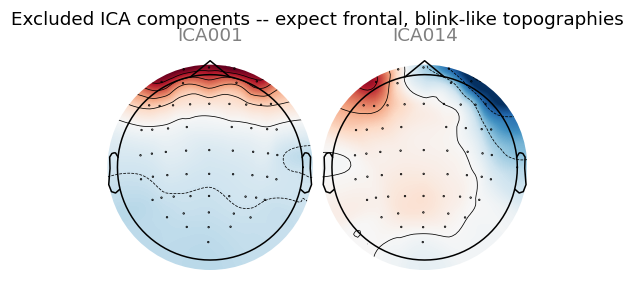

In [13]:
# Topographies of the excluded components: they should look like blinks (frontal, symmetric).
if len(ica.exclude):
    fig = ica.plot_components(picks=list(map(int, ica.exclude)), show=False)
    if not isinstance(fig, list):
        fig = [fig]
    for f in fig:
        f.suptitle("Excluded ICA components -- expect frontal, blink-like topographies", y=1.02)
    plt.show()
else:
    print("no components excluded")


### 2.3 · Spatial filters: SOUND and SSP-SIR

Both are fixed matrices estimated at calibration. A quick conditioning check tells you whether
they are well behaved or close to singular.


In [14]:
def _matrix_report(name, M):
    M = np.asarray(M)
    print(f"{name:34s} shape {str(M.shape):14s}", end="")
    if M.ndim == 2 and M.shape[0] == M.shape[1]:
        s = np.linalg.svd(M, compute_uv=False)
        rank = int((s > s.max() * 1e-12).sum())
        print(f" rank {rank}/{M.shape[0]}  cond {s.max()/max(s.min(),1e-30):.3g}"
              f"  ||M||_F {np.linalg.norm(M):.3g}")
    else:
        print(f" range [{M.min():.3g}, {M.max():.3g}]")


for k in ["sound_filter", "sspsir_suppression_matrix_P",
          "sspsir_sir_projmat_suppr", "sspsir_sir_projmat_orig", "sspsir_filter_kernel"]:
    if k in BUNDLE:
        _matrix_report(k, BUNDLE[k])

S = np.asarray(BUNDLE["sound_filter"])
print(f"\nSOUND diagonal: mean {np.diag(S).mean():.3f}  "
      f"min {np.diag(S).min():.3f}  max {np.diag(S).max():.3f}")
print("  Values far below 1 mark channels SOUND distrusts and shrinks heavily.")
shrunk = [(CH[i], float(np.diag(S)[i])) for i in np.argsort(np.diag(S))[:6]]
print("  most-shrunk channels:", ", ".join(f"{c} {v:.2f}" for c, v in shrunk))


sound_filter                       shape (60, 60)       rank 60/60  cond 5.97e+11  ||M||_F 5.43
sspsir_suppression_matrix_P        shape (60, 60)       rank 52/60  cond 8.83e+15  ||M||_F 7.21
sspsir_sir_projmat_suppr           shape (60, 60)       rank 43/60  cond 8.35e+14  ||M||_F 6.56
sspsir_sir_projmat_orig            shape (60, 60)       rank 43/60  cond 3.43e+15  ||M||_F 6.56
sspsir_filter_kernel               shape (60, 100)      range [0.221, 1]

SOUND diagonal: mean 0.612  min 0.275  max 0.843
  Values far below 1 mark channels SOUND distrusts and shrinks heavily.
  most-shrunk channels: FT7 0.28, FC3 0.43, F5 0.47, F2 0.49, F1 0.50, F7 0.50


### 2.4 · Rejection reference statistics

The MAD gates in sections 3 and 6 compare each trial against these calibration-derived
numbers. They never update during the session.


In [15]:
for key, where in [("good_trial_stats_qc", "pre-stimulus (section 3)"),
                   ("good_trial_stats_post", "post-stimulus (section 6)")]:
    st = BUNDLE[key]
    print(f"{key}  --  used by {where}")
    print(f"   mads_mean {st['mads_mean']:.6g}   mads_std {st['mads_std']:.6g}"
          f"   n trials {len(np.atleast_1d(st['mads']))}")
    m = np.atleast_1d(st["mads"])
    print(f"   calibration MAD distribution: min {m.min():.4g}  median {np.median(m):.4g}"
          f"  max {m.max():.4g}")
    cv = st["mads_std"] / st["mads_mean"] if st["mads_mean"] else np.nan
    print(f"   coefficient of variation {cv:.3f}"
          + ("   <-- very tight, the z-gate will be sensitive" if cv < 0.1 else ""))
    print()

print("ocular_threshold_post (Gate 1 reference, one entry per excluded component):")
for c, info in BUNDLE["ocular_threshold_post"].items():
    tm = info["time_indices_of_interest"]
    print(f"   component {int(c):3d}: mean {info['mean']:.5g}  std {info['std']:.5g}"
          f"  window {len(tm)} samples "
          f"[{tm.min()}, {tm.max()}] -> [{tm.min()+POST_INIT_TMIN*1000:.0f}, "
          f"{tm.max()+POST_INIT_TMIN*1000:.0f}] ms")
print(f"\n   rejection rule: median z over that window > {TRJ['ocular']['z_threshold']}")
print("   NOTE: z is computed on a RECTIFIED (absolute-value) source, so normal-theory")
print("         intuition does not apply. Section 6.2 measures what the threshold really costs.")


good_trial_stats_qc  --  used by pre-stimulus (section 3)
   mads_mean 4.73551   mads_std 1.65212   n trials 114
   calibration MAD distribution: min 2.16  median 4.604  max 9.309
   coefficient of variation 0.349

good_trial_stats_post  --  used by post-stimulus (section 6)
   mads_mean 5.38219   mads_std 2.39339   n trials 112
   calibration MAD distribution: min 2.166  median 4.834  max 15.22
   coefficient of variation 0.445

ocular_threshold_post (Gate 1 reference, one entry per excluded component):
   component   1: mean 0.64578  std 1.0499  window 86 samples [45, 130] -> [15, 100] ms
   component  14: mean 0.62714  std 1.0505  window 86 samples [45, 130] -> [15, 100] ms

   rejection rule: median z over that window > 2
   NOTE: z is computed on a RECTIFIED (absolute-value) source, so normal-theory
         intuition does not apply. Section 6.2 measures what the threshold really costs.


---
## 3 · Pre-stimulus path — `preprocess_pre`

Online this runs **every 10 ms** on a rolling 200 ms window. Its return value is both the QC
verdict (`None` = bad) and, when it passes, the PRIME model's input.

The chain, in order:

1. crop to the QC window, `[-210, -10] ms` at 5 kHz
2. polyphase resample to 1 kHz
3. interpolate the calibration bad channels
4. band-pass with `filtfilt` — **zero-phase, therefore non-causal**
5. subtract the channel mean (average reference)
6. **gate A** — global MAD z against calibration
7. **gate B** — local MAD z across channels
8. return the `[-65, -15] ms` slice

What is replayed here is the **pulse-locked** pre window saved by `save_raw_buffers`, i.e. the
window belonging to the pulse that actually happened. That is exactly what the online code
used for `predetermined_single` trials, so those 80 can be validated directly. For PRIME
trials the online decision was made on the periodic buffer; since `preprocess_pre` crops
before it filters, the two are numerically identical, but the *timing* differs — the periodic
call happened before the pulse, this replay happens after it.


In [16]:
from scipy.stats import median_abs_deviation, zscore
import time as _time

STAGES_WITH_BUFFERS = sorted(INV.index.tolist())
print("stages available for replay:", STAGES_WITH_BUFFERS)


def iter_trials(df, kind="post", desc=""):
    """Yield (row, buffer) for every trial in `df` that has a saved buffer."""
    n, t0 = len(df), _time.time()
    for i, (_, r) in enumerate(df.iterrows()):
        p = buffer_path(r.stage, int(r.trial_in_stage), kind)
        if not p.exists():
            continue
        if desc and (i % 100 == 0 or i == n - 1):
            el = _time.time() - t0
            print(f"\r  {desc}: {i+1}/{n}  ({el:5.1f}s)", end="", flush=True)
        yield r, np.load(p)
    if desc:
        print(f"\r  {desc}: {n}/{n}  done in {_time.time()-t0:.1f}s" + " " * 20)


stages available for replay: ['baseline', 'calibration', 'evaluation_1', 'evaluation_2', 'evaluation_3', 'evaluation_4', 'evaluation_5', 'intervention_block_1', 'intervention_block_2', 'intervention_block_3', 'intervention_block_4']


In [17]:
# ---------------------------------------------------------------- replay preprocess_pre
pre_rows = []
for r, buf in iter_trials(IV, "pre", "preprocess_pre"):
    out = PP.pre_labelled(buf, TS_PRE, from_pulse=True)
    rejected = isinstance(out, str)

    # Statistics for EVERY trial, gates or not: re-run the chain up to the gates.
    trial = PP.pre_upto_gates(buf, TS_PRE, from_pulse=True)
    st = BUNDLE["good_trial_stats_qc"]
    mad_val = median_abs_deviation(trial, axis=(0, 1))
    z_global = float((mad_val - st["mads_mean"]) / st["mads_std"])
    local = median_abs_deviation(trial, axis=1)
    z_local = zscore(local)
    worst = int(np.argmax(np.abs(z_local)))

    pre_rows.append(dict(
        stage=r.stage, trial=int(r.trial_in_stage), condition=r.condition,
        t=float(r.pulse_time),
        outcome=out if rejected else "KEPT",
        z_global=z_global,
        z_local_max=float(np.max(np.abs(z_local))),
        worst_channel=CH[worst],
        n_over_local=int((np.abs(z_local) > TRJ["pre"]["local_zscore_threshold"]).sum()),
        model_shape=None if rejected else tuple(out.shape),
    ))

PRE = pd.DataFrame(pre_rows)
PRE["block"] = PRE.stage
print(f"\nreplayed {len(PRE)} pre-stimulus windows")
display(PRE.outcome.value_counts().to_frame("n"))


  preprocess_pre: 800/800  done in 3.5s                    

replayed 800 pre-stimulus windows


,n
outcome,
KEPT,799
PRE_LOCAL_MAD,1


In [18]:
# ---------------------------------------------------------------- what the model receives
kept = PRE[PRE.outcome == "KEPT"]
shapes = kept.model_shape.value_counts()
exp_model = (len(CH), int(round((MODEL_TMAX - MODEL_TMIN) * PROCESSED_SFREQ)) + 1)
print(f"model input shape(s): {dict(shapes)}")
print(f"expected             : {exp_model}  "
      f"= 60 channels x [{MODEL_TMIN*1000:.0f}, {MODEL_TMAX*1000:.0f}] ms at {PROCESSED_SFREQ:.0f} Hz")
print(f"all trials agree     : {len(shapes) == 1 and list(shapes.index)[0] == exp_model}")

print(f"\nGate A (global MAD z), accept window {TRJ['pre']['global_zscore_threshold']}:")
print(PRE.z_global.describe(percentiles=[.01, .05, .5, .95, .99]).round(3).to_string())
print(f"\nGate B (max |local z|), reject above {TRJ['pre']['local_zscore_threshold']}:")
print(PRE.z_local_max.describe(percentiles=[.5, .95, .99]).round(3).to_string())


model input shape(s): {(60, 51): np.int64(799)}
expected             : (60, 51)  = 60 channels x [-65, -15] ms at 1000 Hz
all trials agree     : True

Gate A (global MAD z), accept window [-8, 4]:
count    800.000
mean       0.398
std        1.130
min       -2.143
1%        -1.595
5%        -1.337
50%        0.339
95%        2.451
99%        3.142
max        3.997

Gate B (max |local z|), reject above 5:
count    800.000
mean       2.631
std        0.544
min        1.647
50%        2.547
95%        3.614
99%        4.272
max        7.618


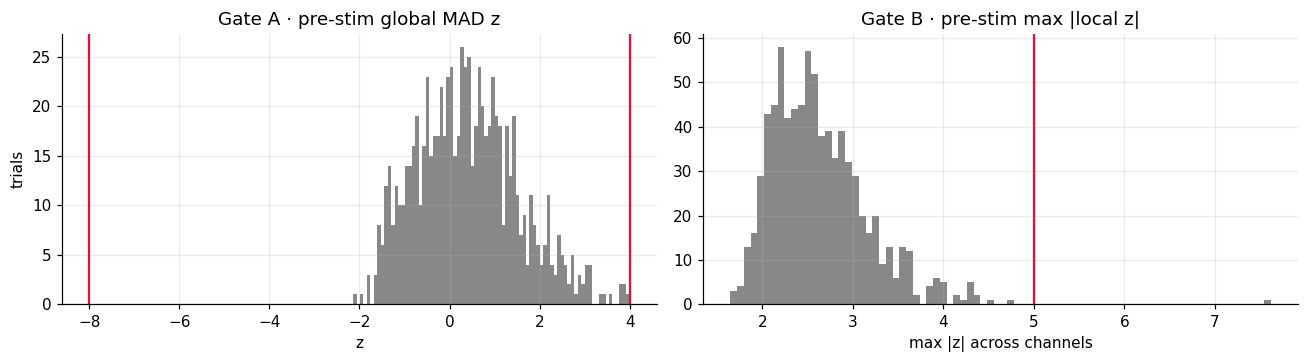

channels responsible for pre-stimulus local-MAD rejections:


,n
worst_channel,
FT7,1


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
lo, hi = TRJ["pre"]["global_zscore_threshold"]
ax[0].hist(PRE.z_global, bins=80, color="#888")
for v in (lo, hi):
    ax[0].axvline(v, color="crimson", lw=1.5)
ax[0].set(title="Gate A · pre-stim global MAD z", xlabel="z", ylabel="trials")

thr = TRJ["pre"]["local_zscore_threshold"]
ax[1].hist(PRE.z_local_max, bins=80, color="#888")
ax[1].axvline(thr, color="crimson", lw=1.5)
ax[1].set(title="Gate B · pre-stim max |local z|", xlabel="max |z| across channels")
plt.tight_layout(); plt.show()

if (PRE.outcome != "KEPT").any():
    print("channels responsible for pre-stimulus local-MAD rejections:")
    display(PRE[PRE.outcome == "PRE_LOCAL_MAD"].worst_channel.value_counts().to_frame("n"))
else:
    print("No pre-stimulus rejections on the pulse-locked windows.")
    print("That is expected: PRIME only fires when the QC already passed, so the saved")
    print("pre buffers are a survivor-biased sample. See section 4 for the true QC rate.")


In [20]:
# ---------------------------------------------------------------- validate against the log
# Only predetermined trials that SURVIVED post-processing are comparable: the online call to
# preprocess_pre_from_pulse sits after the `if not success: return None` guard, so on a trial
# that failed post-processing `preprocessing_failed` stays False simply because the code never
# reached it. Comparing those would manufacture a disagreement that is not real.
pd_tr = IV[(IV.condition == "predetermined_single") & (~IV.postprocessing_failed.astype(bool))]
if "preprocessing_failed" in IV.columns and len(pd_tr):
    m = PRE.merge(pd_tr[["stage", "trial_in_stage", "preprocessing_failed"]],
                  left_on=["stage", "trial"], right_on=["stage", "trial_in_stage"])
    agree = ((m.outcome != "KEPT") == m.preprocessing_failed.astype(bool)).mean()
    n_excl = int((IV.condition == "predetermined_single").sum()) - len(m)
    print(f"predetermined_single trials cross-checked : {len(m)}"
          f"   ({n_excl} excluded -- they failed post-processing, so the online code never")
    print(f"                                              called preprocess_pre on them)")
    print(f"replay agrees with logged preprocessing_failed : {agree*100:.1f}%")
    print("\n  This is the only condition where the online code called preprocess_pre on the")
    print("  pulse-locked buffer, so it is the only one that can be validated this way.")
    if agree < 1:
        display(m[((m.outcome != "KEPT") != m.preprocessing_failed.astype(bool))])


predetermined_single trials cross-checked : 67   (13 excluded -- they failed post-processing, so the online code never
                                              called preprocess_pre on them)
replay agrees with logged preprocessing_failed : 100.0%

  This is the only condition where the online code called preprocess_pre on the
  pulse-locked buffer, so it is the only one that can be validated this way.


### 3.1 · Channel-level view of the pre-stimulus data

Which channels carry the most variance after preprocessing, and does that change over the
session? A channel that climbs here is a channel about to start failing gates.


  per-channel MAD: 400/400  done in 0.9s                    

noisiest channels (median MAD over the sampled trials):


,MAD
Fpz,6.526303
P1,6.417975
Fp2,6.225739
Fp1,6.211197
PO3,6.115116
AF4,6.106096
P3,6.089137
AF8,6.054415


quietest:


,MAD
FC3,3.557719
FC5,3.672249
C3,3.794349
FC6,3.899476
C2,3.972887



channels whose noise grows most over the session (corr with wall-clock time):


,r
Fp1,0.209517
AF7,0.208233
Fpz,0.184100
CPz,0.171420
CP1,0.168817
Fp2,0.167566
AF8,0.161842
F8,0.158941


  A large positive r flags a channel degrading during the recording -- exactly the
  failure mode the frozen calibration bad-channel list cannot catch.


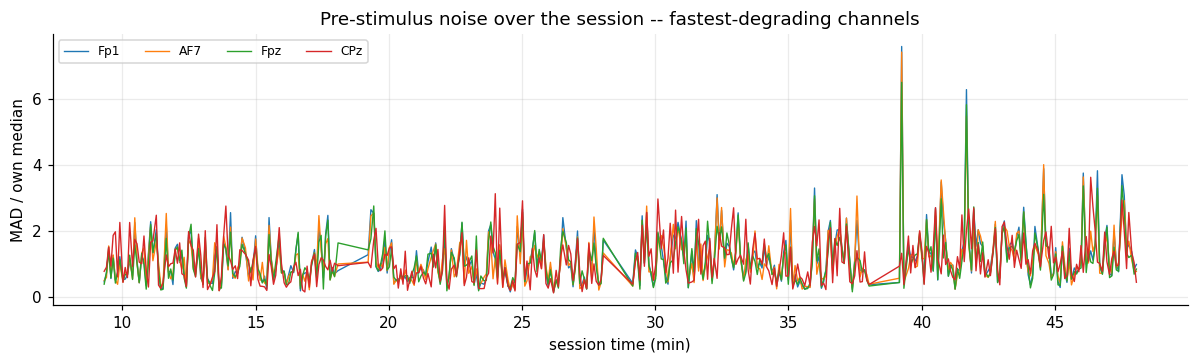

In [21]:
# Per-channel MAD for a sample of trials, tracked across the session.
SAMPLE_EVERY = max(1, len(IV) // 300)
rows = []
for r, buf in iter_trials(IV.iloc[::SAMPLE_EVERY], "pre", "per-channel MAD"):
    trial = PP.pre_upto_gates(buf, TS_PRE, from_pulse=True)
    rows.append(dict(stage=r.stage, trial=int(r.trial_in_stage), t=float(r.pulse_time),
                     **{c: v for c, v in zip(CH, median_abs_deviation(trial, axis=1))}))
CHMAD = pd.DataFrame(rows)

med = CHMAD[CH].median()
print("\nnoisiest channels (median MAD over the sampled trials):")
display(med.sort_values(ascending=False).head(8).to_frame("MAD"))
print("quietest:")
display(med.sort_values().head(5).to_frame("MAD"))

drift = {c: np.corrcoef(CHMAD.t, CHMAD[c])[0, 1] for c in CH}
drift = pd.Series(drift).sort_values(ascending=False)
print("\nchannels whose noise grows most over the session (corr with wall-clock time):")
display(drift.head(8).to_frame("r"))
print("  A large positive r flags a channel degrading during the recording -- exactly the")
print("  failure mode the frozen calibration bad-channel list cannot catch.")

fig, ax = plt.subplots(figsize=(11, 3.4))
for c in drift.head(4).index:
    ax.plot(CHMAD.t / 60, CHMAD[c] / CHMAD[c].median(), lw=.9, label=c)
ax.set(xlabel="session time (min)", ylabel="MAD / own median",
       title="Pre-stimulus noise over the session -- fastest-degrading channels")
ax.legend(ncol=4, fontsize=8); plt.tight_layout(); plt.show()


---
## 4 · QC gating — `check_qc` and the rolling deque

`preprocess_pre` decides whether *one* 200 ms window is clean. `check_qc` decides whether the
recent *history* allows stimulation. Two conditions, both must hold:

1. the last **5** entries are all good
2. at least **80%** of all entries (max 50) are good

The history lives in `self.qc_window_good`, a `deque(maxlen=50)` created once in `__init__`.
`prepare_trial` resets `qc_fail_count`, `prime_attempt_count` and friends — but **not** this
deque. The cells below establish when the loop runs and what that means for the guarantee.


In [22]:
if PREDICTIONS is None:
    print("prime_predictions.csv absent -- section 4 needs it.")
else:
    P = PREDICTIONS.copy()
    first = P.sort_values("attempt").groupby(["stage", "trial_in_stage"], as_index=False).first()

    # If the loop starts at T0 and every failed tick costs one interval, then
    #   t_first = T0 + interval * qc_failures_before_the_first_success
    for interval in (0.010,):
        first["T0"] = first.t_since_trial_start - interval * first.qc_failures_so_far
    print("Implied loop start  T0 = t_first_attempt - 0.010 * qc_failures_so_far")
    print(first.T0.describe(percentiles=[.01, .5, .99]).round(5).to_string())
    consistent = first.T0.round(3).nunique() == 1
    print(f"\nT0 identical on every trial: {consistent}"
          + (f"  -> {first.T0.round(3).iloc[0]} s" if consistent else ""))
    print("Zero variance means the 10 ms cadence and the fixed start are both exact.")


Implied loop start  T0 = t_first_attempt - 0.010 * qc_failures_so_far
count    720.0
mean       2.5
std        0.0
min        2.5
1%         2.5
50%        2.5
99%        2.5
max        2.5

T0 identical on every trial: True  -> 2.5 s
Zero variance means the 10 ms cadence and the fixed start are both exact.


In [23]:
if PREDICTIONS is not None and PROFILES["check_qc"] is not None:
    n_qc = len(PROFILES["check_qc"])
    n_pred = len(PROFILES["predict"]) if PROFILES["predict"] is not None else len(P)
    n_prime_trials = int(IV.condition.str.startswith("prime").sum())
    print(f"check_qc calls in the session : {n_qc}")
    print(f"predict  calls               : {n_pred}")
    print(f"difference                   : {n_qc - n_pred}  = QC failures")
    if "qc_failures" in IV.columns:
        print(f"qc_failures logged in trials : {int(IV.qc_failures.sum())}"
              f"   {'MATCH' if n_qc - n_pred == int(IV.qc_failures.sum()) else 'MISMATCH'}")
    print(f"\nPRIME trials                 : {n_prime_trials}")
    print(f"periodic calls per trial     : {n_qc / max(n_prime_trials,1):.2f}")
    print(f"calls if the loop ran the whole 2.5 s ITI : {250 * n_prime_trials}")
    print("\n-> The loop does not run during the inter-trial interval. It wakes up at the")
    print("   minimum-interval boundary and takes only a few looks before firing.")


check_qc calls in the session : 2213
predict  calls               : 1929
difference                   : 284  = QC failures
qc_failures logged in trials : 284   MATCH

PRIME trials                 : 720
periodic calls per trial     : 3.07
calls if the loop ran the whole 2.5 s ITI : 180000

-> The loop does not run during the inter-trial interval. It wakes up at the
   minimum-interval boundary and takes only a few looks before firing.


In [24]:
if PREDICTIONS is not None:
    n_clean_first = int((first.qc_failures_so_far == 0).sum())
    print(f"trials whose FIRST tick passed QC immediately : {n_clean_first}/{len(first)}"
          f"  ({100*n_clean_first/len(first):.1f}%)")
    print()
    print("Why this matters:")
    print("  check_qc returns False whenever len(history) < 5. `qc_rejecting` IS reset at")
    print("  trial start, so if the deque were also reset we would see a rejection message")
    print("  on the first four ticks of every single trial and this number would be 0.")
    print()
    print("  It is not 0, so the deque carries over. On those trials the '5 recent windows'")
    print("  are 1 fresh window plus 4 that are ~2.5 s stale and sit immediately BEFORE the")
    print("  previous pulse. The 'last 50 ms clean' guarantee is not what it appears to be.")

    # How much wall clock do 50 windows actually span?
    if PROFILES["check_qc"] is not None:
        span_s = (IV.pulse_time.max() - IV.trial_start_time.min())
        per_call = span_s / max(len(PROFILES["check_qc"]), 1)
        print(f"\n  Also: 50 deque entries at {per_call:.2f} s between calls span "
              f"~{50*per_call:.0f} s of wall clock,")
        print(f"  not the 500 ms the code comment describes (that assumes 50 consecutive")
        print(f"  10 ms ticks). The 80% rule is a slow session-quality average.")


trials whose FIRST tick passed QC immediately : 709/720  (98.5%)

Why this matters:
  check_qc returns False whenever len(history) < 5. `qc_rejecting` IS reset at
  trial start, so if the deque were also reset we would see a rejection message
  on the first four ticks of every single trial and this number would be 0.

  It is not 0, so the deque carries over. On those trials the '5 recent windows'
  are 1 fresh window plus 4 that are ~2.5 s stale and sit immediately BEFORE the
  previous pulse. The 'last 50 ms clean' guarantee is not what it appears to be.

  Also: 50 deque entries at 1.05 s between calls span ~53 s of wall clock,
  not the 500 ms the code comment describes (that assumes 50 consecutive
  10 ms ticks). The 80% rule is a slow session-quality average.


,total QC failures,mean per trial,worst trial
stage,,,
intervention_block_1,59.0,0.33,50.0
intervention_block_2,75.0,0.42,61.0
intervention_block_3,70.0,0.39,51.0
intervention_block_4,80.0,0.44,57.0


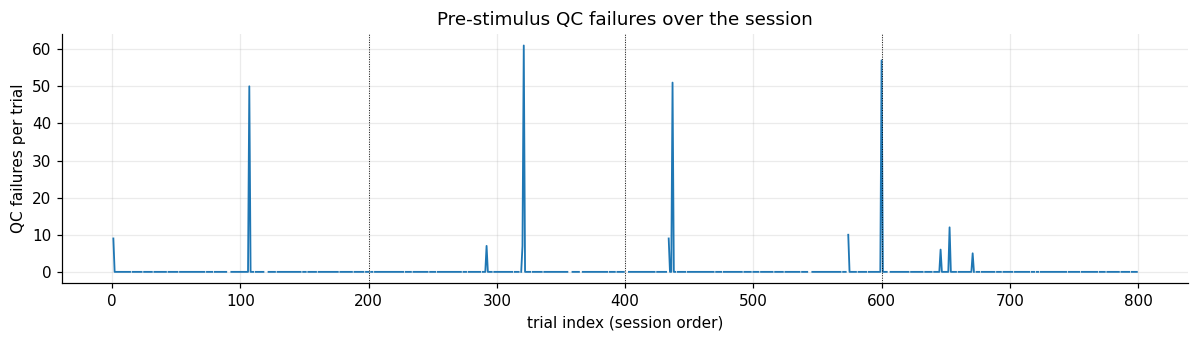

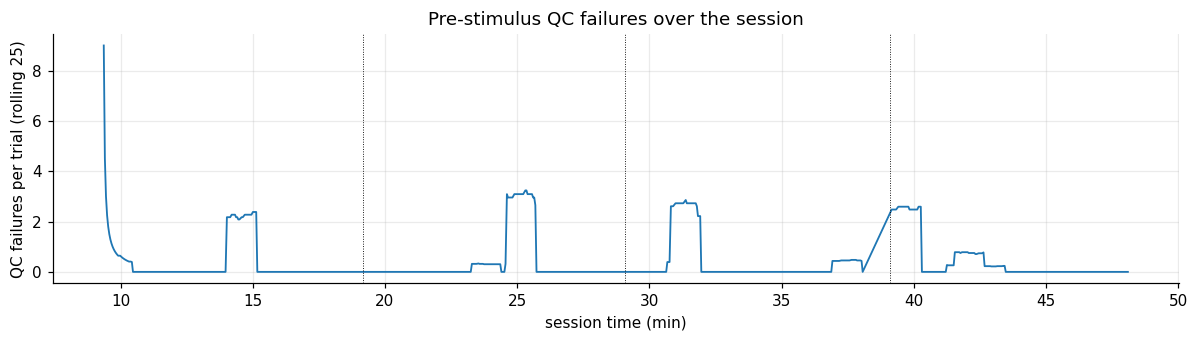

In [53]:
if PREDICTIONS is not None:
    qc = IV.groupby("stage").qc_failures.agg(["sum", "mean", "max"]).round(2)
    qc.columns = ["total QC failures", "mean per trial", "worst trial"]
    display(qc)

    fig, ax = plt.subplots(figsize=(11, 3.2))
    s = IV.sort_values("pulse_time").reset_index(drop=True)
    ax.plot(s.index, s.qc_failures, lw=1.2)
    for b in BLOCKS[1:]:
        first_idx = s.index[s.stage == b].min()
        ax.axvline(first_idx, color="k", lw=.6, ls=":")
    ax.set(xlabel="trial index (session order)", ylabel="QC failures per trial",
           title="Pre-stimulus QC failures over the session")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(11, 3.2))
    s = IV.sort_values("pulse_time")
    ax.plot(s.pulse_time / 60, s.qc_failures.rolling(25, min_periods=1).mean(), lw=1.2)
    for b in BLOCKS[1:]:
        ax.axvline(IV[IV.stage == b].trial_start_time.min() / 60, color="k", lw=.6, ls=":")
    ax.set(xlabel="session time (min)", ylabel="QC failures per trial (rolling 25)",
           title="Pre-stimulus QC failures over the session")
    plt.tight_layout(); plt.show()


---
## 5 · PRIME prediction and triggering

Every 10 ms tick that clears QC produces one classifier call. The pulse is scheduled the
moment `p >= PREDICTION_THRESHOLD`, and fires `TRIGGER_OFFSET` later. If no tick has cleared
by `trial_start + ITI_MAX`, the pulse is forced and no probability is recorded.


In [26]:
PREDICTION_THRESHOLD = 0.5
TRIGGER_OFFSET = 0.010
ITI_MIN, ITI_MAX = 2.5, 5.5

if PREDICTIONS is None:
    print("prime_predictions.csv absent -- this section needs it.")
else:
    print(f"logged attempts : {len(P)}")
    print(f"triggered       : {int(P.triggered.sum())}")
    print(f"forced          : {int(P.forced.sum())}")
    print(f"trials covered  : {P.groupby(['stage','trial_in_stage']).ngroups}")

    ok_hi = bool((P.loc[P.triggered & ~P.forced, "probability"] >= PREDICTION_THRESHOLD).all())
    ok_lo = bool((P.loc[~P.triggered, "probability"] < PREDICTION_THRESHOLD).all())
    print(f"\nthreshold consistency: triggered all >= {PREDICTION_THRESHOLD}: {ok_hi}"
          f" | non-triggered all < {PREDICTION_THRESHOLD}: {ok_lo}")

    dup = P[P.triggered].groupby(["stage", "trial_in_stage"]).size()
    print(f"trials with more than one triggered attempt: {int((dup > 1).sum())}")
    if (dup > 1).any():
        print("  (a counter-reset artefact at block boundaries; harmless but it inflates")
        print("   prime_attempts by one on the affected trials)")
        display(dup[dup > 1].to_frame("n_triggered"))


logged attempts : 1929
triggered       : 722
forced          : 0
trials covered  : 720

threshold consistency: triggered all >= 0.5: True | non-triggered all < 0.5: True
trials with more than one triggered attempt: 2
  (a counter-reset artefact at block boundaries; harmless but it inflates
   prime_attempts by one on the affected trials)


,,n_triggered
stage,trial_in_stage,
intervention_block_2,0,2
intervention_block_4,0,2


attempts needed per trial:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,21,22,23,26,31,34,35,50
n trials,449,64,58,48,20,18,18,9,11,3,3,3,1,2,1,2,2,1,1,1,2,1,1,1


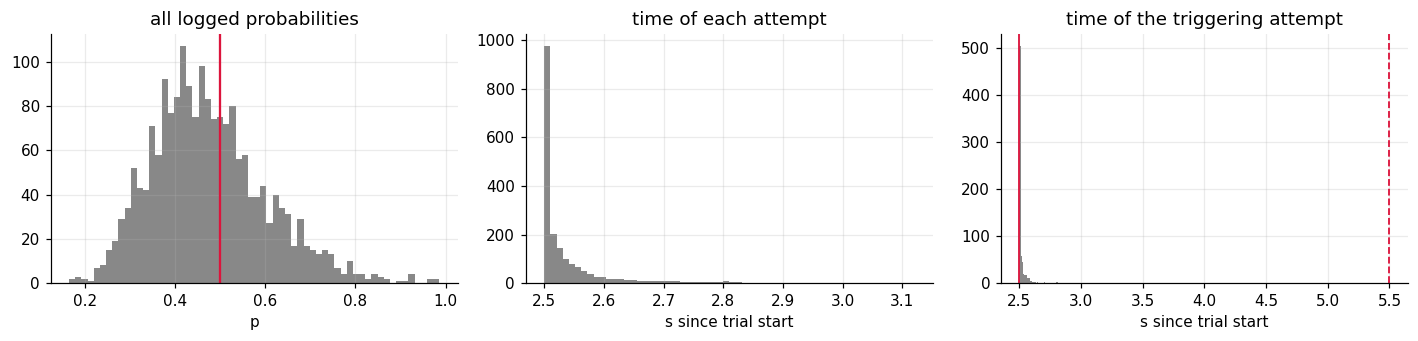

triggering attempt time: median 2.500 s   p95 2.580   max 3.120
headroom to ITI_MAX (5.5 s) used: 20.7% at worst

If that percentage is tiny, the classifier is saturating -- it says yes almost
immediately, so brain-state selection is doing little work. Compare with the
label distribution in section 8.


In [27]:
if PREDICTIONS is not None:
    att = P.groupby(["stage", "trial_in_stage"]).size()
    print("attempts needed per trial:")
    display(att.value_counts().sort_index().to_frame("n trials").T)

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
    ax[0].hist(P.probability.dropna(), bins=60, color="#888")
    ax[0].axvline(PREDICTION_THRESHOLD, color="crimson", lw=1.5)
    ax[0].set(title="all logged probabilities", xlabel="p")

    ax[1].hist(P.t_since_trial_start, bins=60, color="#888")
    ax[1].set(title="time of each attempt", xlabel="s since trial start")

    tr = P[P.triggered].groupby(["stage", "trial_in_stage"]).t_since_trial_start.max()
    ax[2].hist(tr, bins=60, color="#888")
    ax[2].axvline(ITI_MIN, color="crimson", lw=1.2)
    ax[2].axvline(ITI_MAX, color="crimson", lw=1.2, ls="--")
    ax[2].set(title="time of the triggering attempt", xlabel="s since trial start")
    plt.tight_layout(); plt.show()

    print(f"triggering attempt time: median {tr.median():.3f} s   "
          f"p95 {tr.quantile(.95):.3f}   max {tr.max():.3f}")
    print(f"headroom to ITI_MAX ({ITI_MAX} s) used: "
          f"{100*(tr.max()-ITI_MIN)/(ITI_MAX-ITI_MIN):.1f}% at worst")
    print("\nIf that percentage is tiny, the classifier is saturating -- it says yes almost")
    print("immediately, so brain-state selection is doing little work. Compare with the")
    print("label distribution in section 8.")


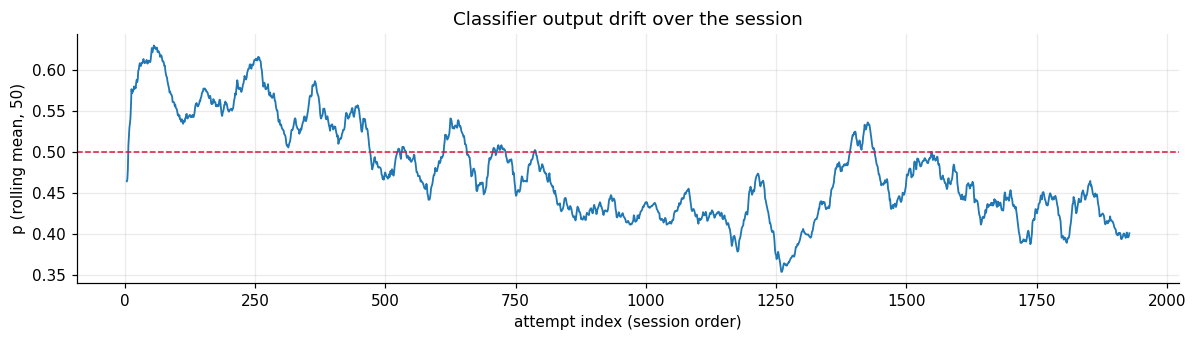

,count,mean,median,std
stage,,,,
intervention_block_1,236,0.5762,0.5594,0.1057
intervention_block_2,372,0.5208,0.4982,0.1206
intervention_block_3,746,0.4380,0.4212,0.1076
intervention_block_4,575,0.4486,0.4278,0.1312



torch is available -- you can additionally reload classifier_after_trial_N.pt
and re-run OnlinePredictor.predict on the saved pre buffers to confirm the
logged probabilities reproduce. Not done here to keep the run time down.


In [28]:
if PREDICTIONS is not None:
    fig, ax = plt.subplots(figsize=(11, 3.2))
    s = P.sort_values(["stage", "trial_in_stage", "attempt"]).reset_index(drop=True)
    ax.plot(s.index, s.probability.rolling(50, min_periods=5).mean(), lw=1.2)
    ax.axhline(PREDICTION_THRESHOLD, color="crimson", lw=1, ls="--")
    ax.set(xlabel="attempt index (session order)", ylabel="p (rolling mean, 50)",
           title="Classifier output drift over the session")
    plt.tight_layout(); plt.show()

    by_block = P.groupby("stage").probability.agg(["count", "mean", "median", "std"]).round(4)
    display(by_block)

if HAVE_TORCH:
    print("\ntorch is available -- you can additionally reload classifier_after_trial_N.pt")
    print("and re-run OnlinePredictor.predict on the saved pre buffers to confirm the")
    print("logged probabilities reproduce. Not done here to keep the run time down.")


---
## 6 · Post-stimulus path — `preprocess_post` and its three gates

This is where trials are actually lost. The chain:

| # | step | window |
|---|---|---|
| 1 | crop + resample to 1 kHz | −30 … +100 ms |
| 2 | baseline correct | −25 … −15 ms |
| 3 | `fix_stim_artifact` | −14 … +14 ms |
| 4 | interpolate bads → average reference | whole epoch |
| 5 | **GATE 1** ocular ICA | +15 … +100 ms |
| 6 | apply ICA → re-baseline → re-reference → crop | +1 … +100 ms |
| 7 | SOUND → SSP-SIR → `fix_stim_artifact` → re-reference | +1 … +15 ms |
| 8 | **GATE 2** global MAD | +20 … +60 ms |
| 9 | **GATE 3** local MAD | +20 … +60 ms |
| 10 | crop → dipole fitter | **+38 … +50 ms** |

Two replays run below. `post_labelled` gives the true decision for each trial;
`post_all_stats` bypasses gates 1 and 2 so that all three gate statistics exist for *every*
trial, including the ones that were discarded early. A consistency assertion ties them
together.


In [29]:
# ---------------------------------------------------------------- the two replays
ocular_comps = list(BUNDLE["ocular_threshold_post"].keys())
st_post = BUNDLE["good_trial_stats_post"]
ICA_OBJ = BUNDLE["ica"]

post_rows = []
for r, buf in iter_trials(IV, "post", "preprocess_post"):
    d = dict(stage=r.stage, trial=int(r.trial_in_stage), condition=r.condition,
             t=float(r.pulse_time),
             logged_fail=bool(r.postprocessing_failed),
             logged_amp=float(r.tep_amplitude_raw) if "tep_amplitude_raw" in r
                              and pd.notna(r.tep_amplitude_raw) else np.nan)

    # (a) the real decision
    out = PP.post_labelled(buf, TS_POST)
    d["outcome"] = out if isinstance(out, str) else "KEPT"
    d["dipole_shape"] = None if isinstance(out, str) else tuple(out.shape)

    # (b) gate-1 statistic, from the epoch just before the ocular check
    ep = PP.post_upto_ocular(buf, TS_POST)
    src = ICA_OBJ.get_sources(ep).get_data(copy=True)
    zs = {}
    for c in ocular_comps:
        info = BUNDLE["ocular_threshold_post"][c]
        z = (np.abs(src[0, int(c), info["time_indices_of_interest"]]) - info["mean"]) / info["std"]
        zs[int(c)] = float(np.median(z))
    d.update({f"ocular_z_c{k}": v for k, v in zs.items()})
    d["ocular_z"] = max(zs.values())

    # (c) MAD statistics for every trial, gates bypassed
    rd = PP.post_all_stats(buf, TS_POST)
    mad_val = median_abs_deviation(rd, axis=(1, 2))[0]
    d["global_z"] = float((mad_val - st_post["mads_mean"]) / st_post["mads_std"])
    zl = zscore(median_abs_deviation(rd, axis=2), axis=1)[0]
    worst = int(np.argmax(np.abs(zl)))
    d["local_z_max"] = float(np.abs(zl).max())
    d["local_worst_channel"] = CH[worst]
    d["local_n_over"] = int((np.abs(zl) > TRJ["post"]["local_zscore_threshold"]).sum())
    d["local_over_channels"] = ",".join(np.array(CH)[np.abs(zl) > TRJ["post"]["local_zscore_threshold"]])
    post_rows.append(d)

POST = pd.DataFrame(post_rows)
print(f"\nreplayed {len(POST)} post-stimulus trials")


  preprocess_post: 800/800  done in 65.3s                    

replayed 800 post-stimulus trials


In [30]:
# ---------------------------------------------------------------- self-consistency
oc_thr = TRJ["ocular"]["z_threshold"]
g_lo, g_hi = TRJ["post"]["global_zscore_threshold"]
l_thr = TRJ["post"]["local_zscore_threshold"]

def _predicted(row):
    if row.ocular_z > oc_thr:
        return "OCULAR_ICA"
    if row.global_z < g_lo or row.global_z > g_hi:
        return "GLOBAL_MAD"
    if row.local_z_max > l_thr:
        return "LOCAL_MAD"
    return "KEPT"

POST["outcome_from_stats"] = POST.apply(_predicted, axis=1)
agree_internal = (POST.outcome == POST.outcome_from_stats).mean()
print(f"labelled clone vs. statistics recomputed from the taps : {agree_internal*100:.2f}%")
if agree_internal < 1:
    display(POST[POST.outcome != POST.outcome_from_stats].head(10))

agree_log = ((POST.outcome != "KEPT") == POST.logged_fail).mean()
print(f"replay vs. the online postprocessing_failed flag       : {agree_log*100:.2f}%")
if agree_log == 1:
    print("\n  Exact. Every number in this section describes the real session.")
else:
    print("\n  *** NOT EXACT -- treat the rest of this section with suspicion. ***")
    display(POST[(POST.outcome != "KEPT") != POST.logged_fail].head(10))


labelled clone vs. statistics recomputed from the taps : 100.00%
replay vs. the online postprocessing_failed flag       : 100.00%

  Exact. Every number in this section describes the real session.


### 6.1 · Attrition: who is lost, and to which gate


In [31]:
tab = pd.crosstab(POST.condition, POST.outcome)
tab["delivered"] = tab.sum(axis=1)
display(tab)

pct = (pd.crosstab(POST.condition, POST.outcome, normalize="index") * 100).round(1)
print("as % of delivered:")
display(pct)

print("\nwhich gate does the losing:")
loss = POST[POST.outcome != "KEPT"].groupby(["condition", "outcome"]).size().unstack(fill_value=0)
display(loss)

# Waterfall: how many survive each successive gate.
order = ["OCULAR_ICA", "GLOBAL_MAD", "LOCAL_MAD"]
n = len(POST)
rows = [("delivered", n, 100.0)]
remaining = n
for g in order:
    lost = int((POST.outcome == g).sum())
    remaining -= lost
    rows.append((f"after {g}", remaining, 100 * remaining / n))
WATERFALL = pd.DataFrame(rows, columns=["stage", "trials remaining", "% of delivered"])
display(WATERFALL.round(1))


outcome,GLOBAL_MAD,KEPT,LOCAL_MAD,OCULAR_ICA,delivered
condition,,,,,
predetermined_single,0,67,0,13,80
prime_single_pulse,0,228,0,12,240
prime_triplet,75,261,85,59,480


as % of delivered:


outcome,GLOBAL_MAD,KEPT,LOCAL_MAD,OCULAR_ICA
condition,,,,
predetermined_single,0.0,83.8,0.0,16.2
prime_single_pulse,0.0,95.0,0.0,5.0
prime_triplet,15.6,54.4,17.7,12.3



which gate does the losing:


outcome,GLOBAL_MAD,LOCAL_MAD,OCULAR_ICA
condition,,,
predetermined_single,0,0,13
prime_single_pulse,0,0,12
prime_triplet,75,85,59


,stage,trials remaining,% of delivered
0,delivered,800,100.0
1,after OCULAR_ICA,716,89.5
2,after GLOBAL_MAD,641,80.1
3,after LOCAL_MAD,556,69.5


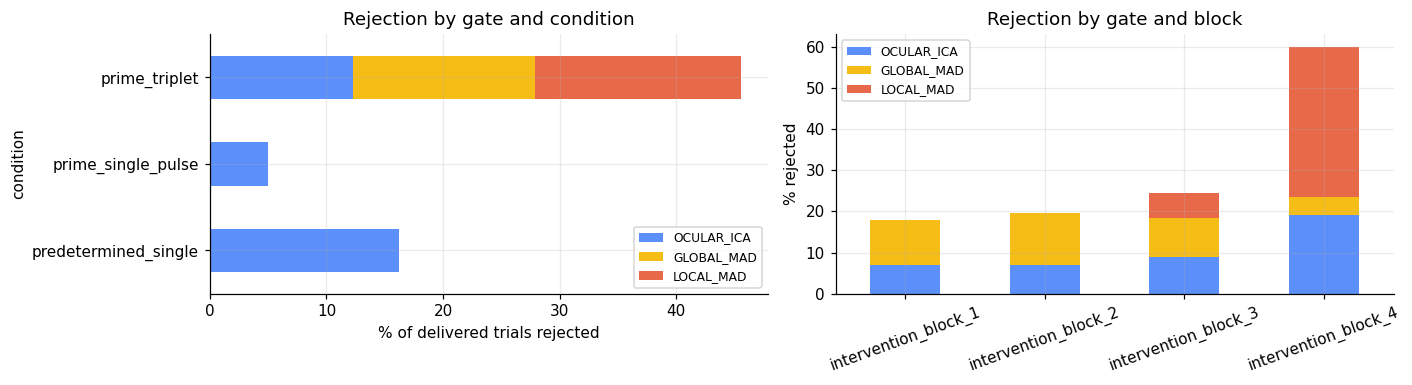

rejection rate (%) by block and condition:


stage,intervention_block_1,intervention_block_2,intervention_block_3,intervention_block_4
condition,,,,
predetermined_single,10.0,10.0,25.0,20.0
prime_single_pulse,3.3,1.7,3.3,11.7
prime_triplet,26.7,30.0,35.0,90.8


In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
pct[[c for c in order if c in pct.columns]].plot(kind="barh", stacked=True, ax=ax[0],
                                                 color=["#5b8ff9", "#f6bd16", "#e8684a"])
ax[0].set(xlabel="% of delivered trials rejected", title="Rejection by gate and condition")
ax[0].legend(fontsize=8)

blk = (pd.crosstab(POST.stage, POST.outcome, normalize="index") * 100)
blk[[c for c in order if c in blk.columns]].plot(kind="bar", stacked=True, ax=ax[1],
                                                 color=["#5b8ff9", "#f6bd16", "#e8684a"])
ax[1].set(ylabel="% rejected", title="Rejection by gate and block", xlabel="")
ax[1].tick_params(axis="x", rotation=20); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("rejection rate (%) by block and condition:")
display((POST.assign(rej=POST.outcome != "KEPT")
             .pivot_table(index="condition", columns="stage", values="rej", aggfunc="mean") * 100
        ).round(1))


### 6.2 · Gate statistics — distributions, thresholds, and what they cost

**The gates are sequential, and that matters for reading these plots.** A trial rejected by
Gate 1 never reaches Gates 2 or 3. But the statistics plotted here are computed with the gates
*bypassed*, so a value exists for every trial — including ones that were already gone.

That means a trial can sit above the Gate 3 threshold and still not appear in the Gate 3
rejection count, because Gate 1 got there first. Each panel therefore draws two lines:

- **solid** — trials that actually *reached* that gate. Mass above the threshold here equals
  the rejections attributed to it.
- **faint dashed** — all trials, gates bypassed. Mass above the threshold here is *not*
  necessarily a rejection by this gate.

The gap between the two lines is the work the earlier gates already did.


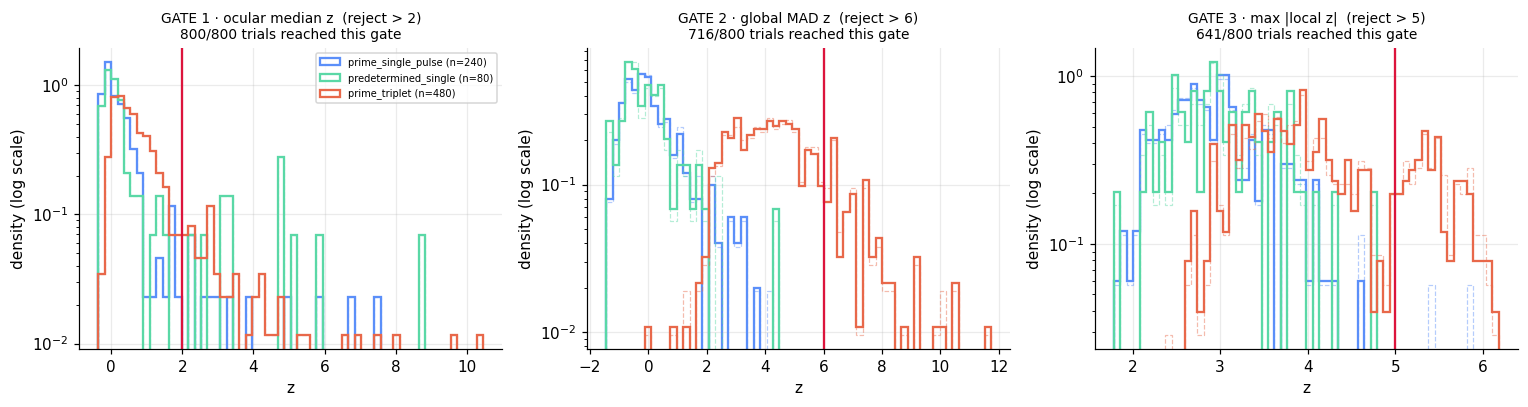

The y-axis is probability DENSITY on a log scale, normalised separately per condition,
so the curves compare shapes rather than trial counts. n is in the legend.

gate statistics by condition (median / 90th pct / max), all trials:


ocular_z                   global_z                   local_z_max                 
                       median <lambda_0>    max   median <lambda_0>    max      median <lambda_0>   max
condition                                                                                              
predetermined_single     0.10       3.29   8.73    -0.14       1.33   4.48        2.97       3.77  4.79
prime_single_pulse       0.06       0.88   7.43    -0.08       1.61   4.21        2.89       3.77  5.83
prime_triplet            0.58       2.31  10.46     4.35       6.69  11.73        4.00       5.52  6.18

In [33]:
# Which trials reached each gate, in the order preprocess_post applies them.
REACHED = {
    "ocular_z":    POST.index,                                             # gate 1 sees all
    "global_z":    POST.index[POST.outcome != "OCULAR_ICA"],               # gate 2
    "local_z_max": POST.index[~POST.outcome.isin(["OCULAR_ICA", "GLOBAL_MAD"])],  # gate 3
}
CONDCOL = {"prime_single_pulse": "#5b8ff9", "predetermined_single": "#5ad8a6",
           "prime_triplet": "#e8684a"}

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, (col, thr, name) in zip(ax, [
        ("ocular_z", oc_thr, f"GATE 1 · ocular median z  (reject > {oc_thr})"),
        ("global_z", g_hi,   f"GATE 2 · global MAD z  (reject > {g_hi})"),
        ("local_z_max", l_thr, f"GATE 3 · max |local z|  (reject > {l_thr})")]):
    reached = REACHED[col]
    lo, hi = POST[col].min(), POST[col].max()
    bins = np.linspace(lo, hi, 61)
    for cond, colr in CONDCOL.items():
        allv = POST.loc[POST.condition == cond, col]
        rchv = POST.loc[reached.intersection(POST.index[POST.condition == cond]), col]
        if not len(allv):
            continue
        a.hist(allv, bins=bins, histtype="step", lw=.8, ls="--", color=colr, alpha=.45,
               density=True)
        if len(rchv):
            a.hist(rchv, bins=bins, histtype="step", lw=1.5, color=colr, density=True,
                   label=f"{cond} (n={len(rchv)})")
    a.axvline(thr, color="crimson", lw=1.5)
    a.set(title=f"{name}\n{len(reached)}/{len(POST)} trials reached this gate",
          xlabel="z", ylabel="density (log scale)", yscale="log")
    a.title.set_fontsize(9)
ax[0].legend(fontsize=6.5)
plt.tight_layout(); plt.show()

print("The y-axis is probability DENSITY on a log scale, normalised separately per condition,")
print("so the curves compare shapes rather than trial counts. n is in the legend.\n")

print("gate statistics by condition (median / 90th pct / max), all trials:")
display(POST.groupby("condition")[["ocular_z", "global_z", "local_z_max"]]
            .agg(["median", lambda x: x.quantile(.9), "max"]).round(2))


In [34]:
# Make the sequencing explicit: who is above each threshold, and what actually killed them.
print("Trials above each gate's threshold, split by the outcome actually recorded.")
print("Anything off the diagonal was already dead when this gate would have fired.\n")
for col, thr, gate in [("ocular_z", oc_thr, "OCULAR_ICA"),
                       ("global_z", g_hi, "GLOBAL_MAD"),
                       ("local_z_max", l_thr, "LOCAL_MAD")]:
    over = POST[POST[col] > thr]
    print(f"--- {gate}: {len(over)} trials have {col} > {thr}")
    if len(over):
        display(pd.crosstab(over.condition, over.outcome))
    n_att = int((POST.outcome == gate).sum())
    n_earlier = len(over) - int((over.outcome == gate).sum())
    print(f"    attributed to {gate}: {n_att}"
          f"   |   above threshold but killed earlier: {n_earlier}\n")

print("Sanity checks:")
for col, thr, gate in [("ocular_z", oc_thr, "OCULAR_ICA"),
                       ("global_z", g_hi, "GLOBAL_MAD"),
                       ("local_z_max", l_thr, "LOCAL_MAD")]:
    bad = POST[(POST.outcome == "KEPT") & (POST[col] > thr)]
    print(f"  KEPT trials above the {gate} threshold: {len(bad)}  "
          f"{'OK' if len(bad) == 0 else '<-- IMPOSSIBLE, investigate'}")


Trials above each gate's threshold, split by the outcome actually recorded.
Anything off the diagonal was already dead when this gate would have fired.

--- OCULAR_ICA: 84 trials have ocular_z > 2


outcome,OCULAR_ICA
condition,
predetermined_single,13
prime_single_pulse,12
prime_triplet,59


    attributed to OCULAR_ICA: 84   |   above threshold but killed earlier: 0

--- GLOBAL_MAD: 86 trials have global_z > 6


outcome,GLOBAL_MAD,OCULAR_ICA
condition,,
prime_triplet,75,11


    attributed to GLOBAL_MAD: 75   |   above threshold but killed earlier: 11

--- LOCAL_MAD: 127 trials have local_z_max > 5


outcome,GLOBAL_MAD,LOCAL_MAD,OCULAR_ICA
condition,,,
prime_single_pulse,0,0,2
prime_triplet,12,85,28


    attributed to LOCAL_MAD: 85   |   above threshold but killed earlier: 42

Sanity checks:
  KEPT trials above the OCULAR_ICA threshold: 0  OK
  KEPT trials above the GLOBAL_MAD threshold: 0  OK
  KEPT trials above the LOCAL_MAD threshold: 0  OK


In [35]:
# What would a different threshold cost? Sweep each gate independently.
print("rejection rate (%) if the gate-1 threshold were moved:")
sweep = []
for thr in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]:
    row = {"threshold": thr, "all": 100 * (POST.ocular_z > thr).mean()}
    for c in POST.condition.unique():
        row[c] = 100 * (POST.loc[POST.condition == c, "ocular_z"] > thr).mean()
    sweep.append(row)
SWEEP1 = pd.DataFrame(sweep).set_index("threshold").round(1)
display(SWEEP1)
if {"predetermined_single", "prime_single_pulse"} <= set(SWEEP1.columns):
    ratio = (SWEEP1["predetermined_single"] / SWEEP1["prime_single_pulse"]).round(2)
    print("ratio predetermined / prime singles at each threshold:")
    display(ratio.to_frame("ratio"))
    print("  If the ratio grows as the gate tightens, a stricter threshold makes the")
    print("  condition imbalance WORSE, not better.")

print("\nrejection rate (%) if the gate-3 threshold were moved:")
sweep = []
for thr in [3, 4, 5, 6, 8, 10]:
    row = {"threshold": thr, "all": 100 * (POST.local_z_max > thr).mean()}
    for c in POST.condition.unique():
        row[c] = 100 * (POST.loc[POST.condition == c, "local_z_max"] > thr).mean()
    sweep.append(row)
display(pd.DataFrame(sweep).set_index("threshold").round(1))


rejection rate (%) if the gate-1 threshold were moved:


,all,predetermined_single,prime_triplet,prime_single_pulse
threshold,,,,
1.0,23.5,21.2,30.8,9.6
1.5,14.2,17.5,17.1,7.5
2.0,10.5,16.2,12.3,5.0
2.5,8.0,15.0,9.0,3.8
3.0,5.2,13.8,5.2,2.5
4.0,3.5,8.8,3.5,1.7
5.0,1.8,3.8,1.7,1.2


ratio predetermined / prime singles at each threshold:


,ratio
threshold,
1.0,2.21
1.5,2.33
2.0,3.24
2.5,3.95
3.0,5.52
4.0,5.18
5.0,3.17


  If the ratio grows as the gate tightens, a stricter threshold makes the
  condition imbalance WORSE, not better.

rejection rate (%) if the gate-3 threshold were moved:


,all,predetermined_single,prime_triplet,prime_single_pulse
threshold,,,,
3,74.4,47.5,94.8,42.5
4,31.9,3.8,50.0,5.0
5,15.9,0.0,26.0,0.8
6,0.9,0.0,1.5,0.0
8,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0


### 6.3 · Development across the session

A gate that drifts is a gate whose reference statistics no longer describe the data. All three
references are frozen at calibration, so any systematic climb here is a calibration mismatch
rather than a change in data quality alone.


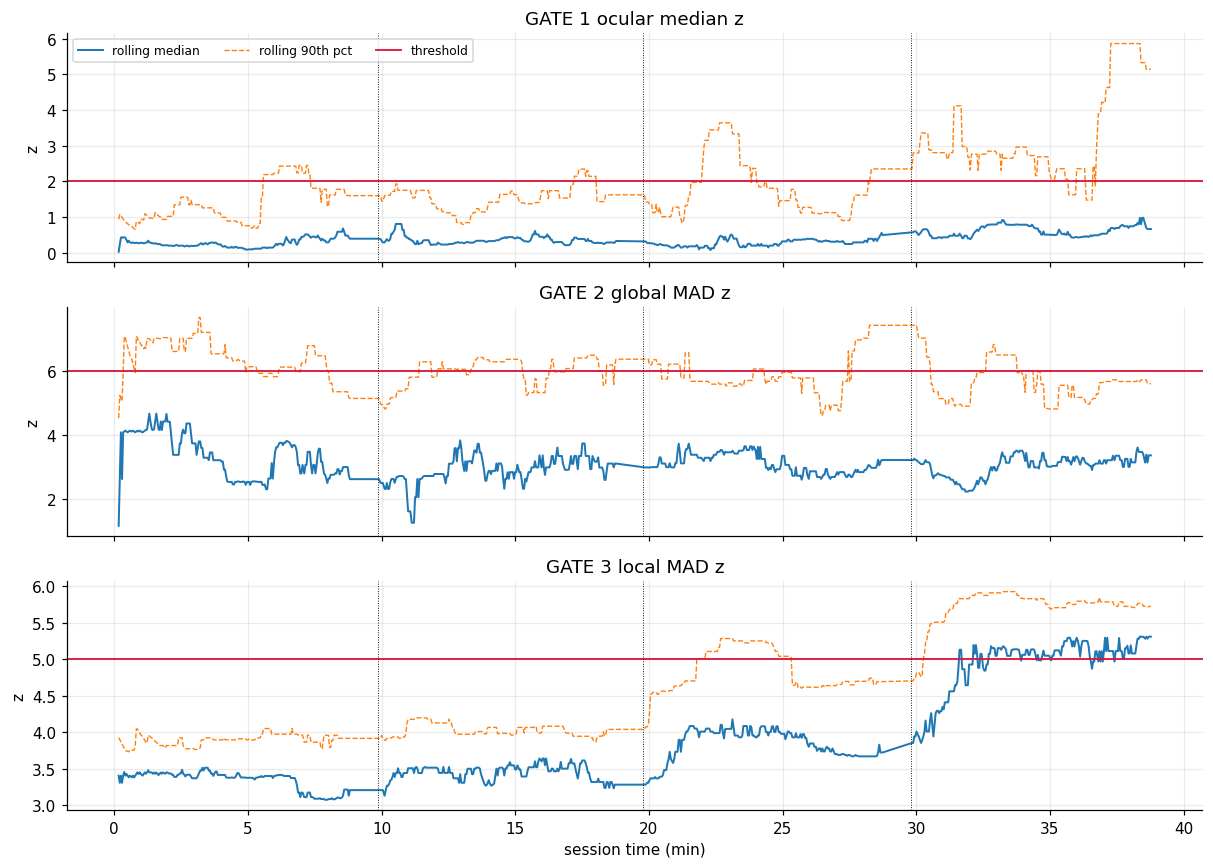

gate statistics by block (median):


,ocular_z,global_z,local_z_max
stage,,,
intervention_block_1,0.258,3.022,3.360
intervention_block_2,0.321,2.926,3.390
intervention_block_3,0.298,3.118,3.894
intervention_block_4,0.658,2.891,5.127



calibration-vs-online shift is quantified in section 6.5.


In [54]:
S = POST.sort_values("t").reset_index(drop=True)
S["min"] = (S.t - S.t.min()) / 60
W = 40

fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for a, (col, thr, name) in zip(ax, [
        ("ocular_z", oc_thr, "GATE 1 ocular median z"),
        ("global_z", g_hi,   "GATE 2 global MAD z"),
        ("local_z_max", l_thr, "GATE 3 local MAD z")]):
    a.plot(S["min"], S[col].rolling(W, min_periods=5).median(), lw=1.3, label="rolling median")
    a.plot(S["min"], S[col].rolling(W, min_periods=5).quantile(.9), lw=.9, ls="--",
           label="rolling 90th pct")
    a.axhline(thr, color="crimson", lw=1.2, label="threshold")
    for b in BLOCKS[1:]:
        a.axvline((IV[IV.stage == b].trial_start_time.min() - S.t.min()) / 60,
                  color="k", lw=.6, ls=":")
    a.set(ylabel="z", title=name)
ax[0].legend(fontsize=8, ncol=3)
ax[-1].set(xlabel="session time (min)")
plt.tight_layout(); plt.show()

print("gate statistics by block (median):")
display(POST.groupby("stage")[["ocular_z", "global_z", "local_z_max"]].median().round(3))
print("\ncalibration-vs-online shift is quantified in section 6.5.")


### 6.4 · Gate 3 attribution — which channel is doing the rejecting

Gate 3 z-scores each channel's MAD *against the other channels in the same trial*, so a single
degrading electrode can dominate it. If one channel name accounts for most rejections, that is
a hardware problem masquerading as a data-quality problem.


trials rejected by GATE 3: 85

worst channel on each rejected trial:


,n
local_worst_channel,
O2,85


every channel that exceeded the threshold on any rejected trial:


,n
O2,85



by block:


local_worst_channel,O2
stage,
intervention_block_3,12
intervention_block_4,73



-> O2 accounts for 100% of gate-3 rejections.
   Is it in the calibration bad-channel list? False
   It is NOT, so it was never interpolated. O2 degraded during the
   session and the frozen bad-channel list could not catch it.
   Offline fix: add 'O2' to the bad list and reprocess.


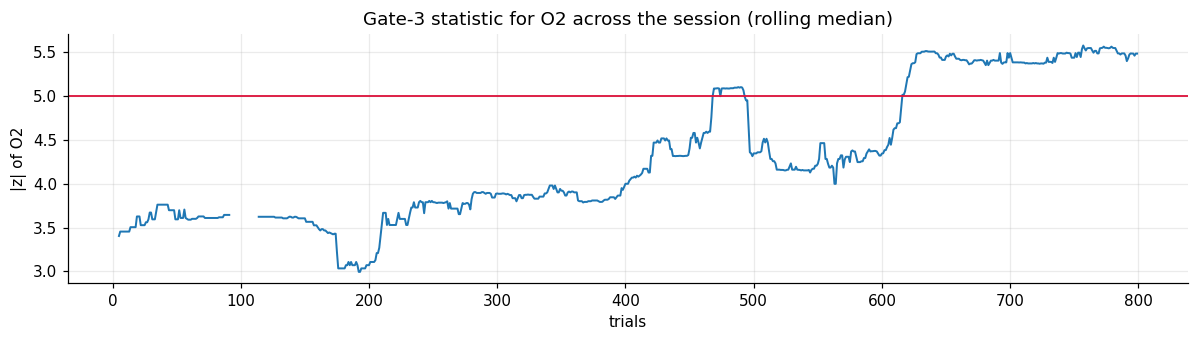

In [55]:
rej3 = POST[POST.outcome == "LOCAL_MAD"]
print(f"trials rejected by GATE 3: {len(rej3)}")
if len(rej3):
    print("\nworst channel on each rejected trial:")
    display(rej3.local_worst_channel.value_counts().to_frame("n"))

    allover = Counter(c for s in rej3.local_over_channels for c in s.split(",") if c)
    print("every channel that exceeded the threshold on any rejected trial:")
    display(pd.Series(dict(allover)).sort_values(ascending=False).to_frame("n"))

    print("\nby block:")
    display(pd.crosstab(rej3.stage, rej3.local_worst_channel))

    dominant = rej3.local_worst_channel.value_counts()
    top, share = dominant.index[0], dominant.iloc[0] / len(rej3)
    print(f"\n-> {top} accounts for {share:.0%} of gate-3 rejections.")
    if share > 0.5:
        in_bads = top in bads
        print(f"   Is it in the calibration bad-channel list? {in_bads}")
        if not in_bads:
            print(f"   It is NOT, so it was never interpolated. {top} degraded during the")
            print(f"   session and the frozen bad-channel list could not catch it.")
            print(f"   Offline fix: add {top!r} to the bad list and reprocess.")

    # Track that channel's z across the whole session, rejected or not.
    fig, ax = plt.subplots(figsize=(11, 3.2))
    sub = POST.sort_values("t")
    zt = []
    for _, r in sub.iterrows():
        zt.append(r.local_z_max if r.local_worst_channel == top else np.nan)
    ax.plot(np.arange(len(sub)), pd.Series(zt).rolling(30, min_periods=3).median(), lw=1.3)
    ax.axhline(l_thr, color="crimson", lw=1.2)
    ax.set(xlabel="trials", ylabel=f"|z| of {top}",
           title=f"Gate-3 statistic for {top} across the session (rolling median)")
    plt.tight_layout(); plt.show()
else:
    print("no gate-3 rejections")


### 6.5 · Are the frozen references still valid?

Score the **calibration** trials with the same gates that judge the intervention trials. If
the calibration set itself would fail at an appreciable rate, the threshold is a rejection-rate
setting rather than a physical criterion; if the intervention statistics sit systematically
above the calibration ones, the gate has silently tightened.


In [38]:
cal_files = sorted(SUBJECT_DIR.glob("calibration_*_post_raw.npy"))
cal_rows = []
for i, f in enumerate(cal_files):
    if i % 25 == 0:
        print(f"\r  calibration trials: {i+1}/{len(cal_files)}", end="", flush=True)
    buf = np.load(f)
    ep = PP.post_upto_ocular(buf, TS_POST)
    src = ICA_OBJ.get_sources(ep).get_data(copy=True)
    oz = max(float(np.median((np.abs(src[0, int(c), BUNDLE["ocular_threshold_post"][c]["time_indices_of_interest"]])
                              - BUNDLE["ocular_threshold_post"][c]["mean"])
                             / BUNDLE["ocular_threshold_post"][c]["std"]))
             for c in ocular_comps)
    rd = PP.post_all_stats(buf, TS_POST)
    mv = median_abs_deviation(rd, axis=(1, 2))[0]
    gz = float((mv - st_post["mads_mean"]) / st_post["mads_std"])
    lz = float(np.abs(zscore(median_abs_deviation(rd, axis=2), axis=1)[0]).max())
    cal_rows.append(dict(trial=i, ocular_z=oz, global_z=gz, local_z_max=lz))
CALPOST = pd.DataFrame(cal_rows)
print(f"\r  calibration trials: {len(cal_files)}/{len(cal_files)} done" + " " * 15)

comp = pd.DataFrame({
    "calibration (median)": CALPOST[["ocular_z", "global_z", "local_z_max"]].median(),
    "intervention (median)": POST[["ocular_z", "global_z", "local_z_max"]].median(),
}).round(3)
comp["shift"] = (comp["intervention (median)"] - comp["calibration (median)"]).round(3)
display(comp)

print("self-consistency -- % of CALIBRATION trials that would fail each gate:")
print(f"   GATE 1 ocular  (> {oc_thr}) : {100*(CALPOST.ocular_z > oc_thr).mean():5.1f}%")
print(f"   GATE 2 global  (> {g_hi}) : {100*(CALPOST.global_z > g_hi).mean():5.1f}%")
print(f"   GATE 3 local   (> {l_thr}) : {100*(CALPOST.local_z_max > l_thr).mean():5.1f}%")
print("\nA gate-1 figure near 10% confirms the threshold is set to a rejection RATE, not to a")
print("residual-artifact tolerance. Note also that the statistic is a z of a RECTIFIED")
print("quantity, so 'z > 2' does not carry its usual tail probability.")


  calibration trials: 125/125 done               


,calibration (median),intervention (median),shift
ocular_z,0.128,0.374,0.246
global_z,-0.202,2.989,3.191
local_z_max,2.829,3.575,0.746


self-consistency -- % of CALIBRATION trials that would fail each gate:
   GATE 1 ocular  (> 2) :   8.0%
   GATE 2 global  (> 6) :   0.0%
   GATE 3 local   (> 5) :   1.6%

A gate-1 figure near 10% confirms the threshold is set to a rejection RATE, not to a
residual-artifact tolerance. Note also that the statistic is a z of a RECTIFIED
quantity, so 'z > 2' does not carry its usual tail probability.


---
## 7 · Dipole fit — the TEP amplitude

`DipoleFitter.calibrate()` picks a source position, an orientation and a sub-window of the
`[38, 50] ms` dipole range from the **calibration average**, stores them in `fitting_info`, and
then applies them unchanged to every single trial. `fit_trial` scans the stored sub-window for
the sample with the best R², and returns the dipole amplitude there.

**`fitting_info` is never written to disk.** It has to be reconstructed here by re-running the
calibration path, which means this section is the one place where the replay is not guaranteed
to be bit-identical to the online run: online, calibration went through `preprocess_calibration`
(a batch routine that also *estimates* SOUND and SSP-SIR), whereas the replay applies the
already-stored filters via `preprocess_post`. The validation cell measures how much that
matters — and if the agreement is poor, the fix is to save `fitting_info` alongside the
calibration bundle in future sessions.


In [39]:
# ---------------------------------------------------------------- calibration dipole buffers
cal_buffers, cal_kept = [], []
for i, f in enumerate(cal_files):
    if i % 25 == 0:
        print(f"\r  preprocess_post on calibration: {i+1}/{len(cal_files)}", end="", flush=True)
    out = PP.preprocess_post(np.load(f), TS_POST)
    if out is not None:
        cal_buffers.append(out); cal_kept.append(i)
cal_buffers = np.asarray(cal_buffers)
print(f"\r  preprocess_post on calibration: {len(cal_files)}/{len(cal_files)} done" + " " * 12)
print(f"calibration trials surviving the replay : {len(cal_buffers)}/{len(cal_files)}")
if CALSUM is not None:
    n_online = int(CALSUM.iloc[0, 0])
    print(f"trials the online calibration kept      : {n_online}")
    print(f"difference                              : {len(cal_buffers) - n_online}")
    print("  (a small difference is expected: the online batch path drops trials at points")
    print("   the single-trial path does not have. Section 7.2 shows what it costs.)")
print(f"dipole buffer shape                     : {cal_buffers.shape}")


  preprocess_post on calibration: 125/125 done            
calibration trials surviving the replay : 113/125
trials the online calibration kept      : 112
difference                              : 1
  (a small difference is expected: the online batch path drops trials at points
   the single-trial path does not have. Section 7.2 shows what it costs.)
dipole buffer shape                     : (113, 60, 13)


In [40]:
# ---------------------------------------------------------------- reconstruct fitting_info
# If a future session saves fitting_info next to the bundle, it is used verbatim and this
# whole section becomes exact. Otherwise it is re-derived from the replayed calibration.
FI_PATH = SUBJECT_DIR / "dipole_fitting_info.npy"
DF = DipoleFitter(FORWARD)

if FI_PATH.exists():
    DF._fitting_info = np.load(FI_PATH, allow_pickle=True).item()
    CAL_AMPS = np.array([DF.fit_trial(cal_buffers[i]) for i in range(len(cal_buffers))])
    FI_SOURCE = "loaded from disk (exact)"
else:
    CAL_AMPS = DF.calibrate(cal_buffers)
    FI_SOURCE = "re-derived from the replayed calibration (approximate)"
FI = DF.fitting_info
print(f"fitting_info: {FI_SOURCE}\n")

# index_range is a (start, end) tuple, sliced as data[:, start:end] -- end is EXCLUSIVE.
I_START, I_END = int(FI["index_range"][0]), int(FI["index_range"][1])
N_WIN = I_END - I_START
MS_PER_SAMPLE = 1000 / PROCESSED_SFREQ
t0 = DIP_TMIN * 1000 + I_START * MS_PER_SAMPLE
t1 = DIP_TMIN * 1000 + (I_END - 1) * MS_PER_SAMPLE

print("reconstructed fitting_info")
print(f"  position index  : {FI['position_index']}")
print(f"  orientation     : {np.round(FI['orientation'], 4)}  (|o| = {np.linalg.norm(FI['orientation']):.6f})")
print(f"  index range     : {tuple(FI['index_range'])}  (start inclusive, end exclusive)")
print(f"  -> time window  : [{t0:.0f}, {t1:.0f}] ms   ({N_WIN} samples)")
print(f"     inside the dipole range [{DIP_TMIN*1000:.0f}, {DIP_TMAX*1000:.0f}] ms: "
      f"{DIP_TMIN*1000 - 1e-9 <= t0 and t1 <= DIP_TMAX*1000 + 1e-9}")
print(f"  window size limits: min {DF._min_window_size}, max {DF._max_window_size}, "
      f"exponent {DF._window_size_exponent}")
print(f"     -> {N_WIN} samples is "
      f"{'at the MINIMUM' if N_WIN == DF._min_window_size else 'at the MAXIMUM' if N_WIN == DF._max_window_size else 'interior to'}"
      " the allowed range")

pos = DF._forward["source_rr"][FI["position_index"]]
print(f"\n  source location (head coords, m): {np.round(pos, 4)}")
print(f"  hemisphere: {'left' if pos[0] < 0 else 'right'}")

print(f"\ncalibration amplitudes: n={len(CAL_AMPS)}  median {np.median(CAL_AMPS):.4g}"
      f"  IQR [{np.percentile(CAL_AMPS,25):.4g}, {np.percentile(CAL_AMPS,75):.4g}]")


fitting_info: re-derived from the replayed calibration (approximate)

reconstructed fitting_info
  position index  : 2111
  orientation     : [-0.3077  0.951   0.0316]  (|o| = 1.000000)
  index range     : (1, 7)  (start inclusive, end exclusive)
  -> time window  : [39, 44] ms   (6 samples)
     inside the dipole range [38, 50] ms: True
  window size limits: min 3, max 6, exponent 1.5
     -> 6 samples is at the MAXIMUM the allowed range

  source location (head coords, m): [-0.0072 -0.0002  0.1099]
  hemisphere: left

calibration amplitudes: n=113  median 0.1278  IQR [0.08891, 0.1814]


In [41]:
# ---------------------------------------------------------------- verbose single-trial fit
import prime_core.preprocessing.dipole_fitter as DFMOD

def make_verbose_single_trial():
    """Clone get_single_trial_dipole so it also reports R2, latency and orientation.

    Two mechanical edits, both asserted below: record the winning time index, and return a
    dict instead of a bare float.
    """
    src_txt = inspect.getsource(DFMOD.get_single_trial_dipole)
    lines, out, patched = src_txt.split("\n"), [], 0
    for ln in lines:
        out.append(ln)
        if ln.strip().startswith("best_amplitude = amplitude"):
            indent = ln[:len(ln) - len(ln.lstrip())]
            out.append(f"{indent}best_time_index = time_index")
            patched += 1
    txt = "\n".join(out)
    old = [l for l in txt.split("\n") if l.strip() == "return best_amplitude"]
    assert patched == 1 and len(old) == 1, (patched, len(old))
    ind = old[0][:len(old[0]) - len(old[0].lstrip())]
    txt = txt.replace(old[0],
                      f"{ind}return dict(amplitude=best_amplitude, r2=best_r2, "
                      f"time_index=best_time_index, moment=best_dipole_moment)")
    txt = txt.replace("def get_single_trial_dipole(", "def get_single_trial_dipole_verbose(", 1)
    ns = dict(vars(DFMOD))
    exec(compile(txt, "<verbose dipole>", "exec"), ns)
    return ns["get_single_trial_dipole_verbose"]


_verbose = make_verbose_single_trial()


def fit_verbose(epoch, orientation="free"):
    """Mirror fit_dipole_to_single_trial's setup exactly, then call the verbose scanner.

    Three details of prime's version that are easy to get wrong and are reproduced here:
    the leadfield is average-referenced before use; `index_range` is a (start, end) slice
    with an exclusive end; and the fixed-orientation amplitude is returned as |a|.
    """
    fwd, pi = DF._forward, FI["position_index"]
    start, end = int(FI["index_range"][0]), int(FI["index_range"][1])
    ori = FI["orientation"] if orientation == "fixed" else None

    L = fwd["sol"]["data"] - np.mean(fwd["sol"]["data"], axis=0)   # average reference
    lf_at_pos = L[:, 3 * pi:3 * pi + 3]
    if ori is not None:
        lf_in_ori, lf_pinv = np.matmul(lf_at_pos, ori), None
    else:
        lf_in_ori, lf_pinv = None, np.linalg.pinv(lf_at_pos)

    out = _verbose(np.asarray(epoch)[:, start:end], ori, lf_in_ori, lf_at_pos, lf_pinv)
    if ori is not None:
        out["amplitude"] = abs(out["amplitude"])
    return out


# Guarantee the verbose clone matches prime's own fit_trial exactly.
_chk = [(fit_verbose(cal_buffers[i])["amplitude"], DF.fit_trial(cal_buffers[i]))
        for i in range(min(25, len(cal_buffers)))]
_d = max(abs(a - b) for a, b in _chk)
print(f"verbose clone vs prime's fit_trial, max |difference| over {len(_chk)} trials: {_d:.3e}")
assert _d < 1e-9, "the verbose clone diverges from prime's fit_trial"
print("identical -- the extra outputs below are safe to read.")


verbose clone vs prime's fit_trial, max |difference| over 25 trials: 0.000e+00
identical -- the extra outputs below are safe to read.


In [42]:
# ---------------------------------------------------------------- fit every surviving trial
dip_rows = []
kept_idx = POST.index[POST.outcome == "KEPT"]
for k, i in enumerate(kept_idx):
    r = POST.loc[i]
    if k % 100 == 0:
        print(f"\r  dipole fits: {k+1}/{len(kept_idx)}", end="", flush=True)
    ep = PP.preprocess_post(np.load(buffer_path(r.stage, int(r.trial), "post")), TS_POST)
    if ep is None:
        continue
    free = fit_verbose(ep, "free")
    fixed = fit_verbose(ep, "fixed")
    lat = DIP_TMIN * 1000 + (I_START + free["time_index"]) * MS_PER_SAMPLE
    ori = free["moment"] / np.linalg.norm(free["moment"])
    dip_rows.append(dict(
        stage=r.stage, trial=int(r.trial), condition=r.condition, t=r.t,
        amp_free=free["amplitude"], r2_free=free["r2"], latency_ms=lat,
        amp_fixed=fixed["amplitude"], r2_fixed=fixed["r2"],
        ori_dot=float(np.dot(ori, FI["orientation"])),
        logged_amp=r.logged_amp))
DIP = pd.DataFrame(dip_rows)
print(f"\r  dipole fits: {len(DIP)}/{len(kept_idx)} done" + " " * 20)


  dipole fits: 556/556 done                    


### 7.1 · Does the replay reproduce the amplitudes the session logged?


,n,pearson,spearman,median_rel_err_pct,p95_rel_err_pct,max_abs_diff
group,,,,,,
ALL,556,0.9059,0.9311,6.6084,122.1243,2.5227
predetermined_single,67,0.9902,0.9846,4.3775,12.0983,0.0390
prime_single_pulse,228,0.9936,0.9919,4.6239,13.3367,0.0358
prime_triplet,261,0.2042,0.3611,46.3301,128.6352,2.5227


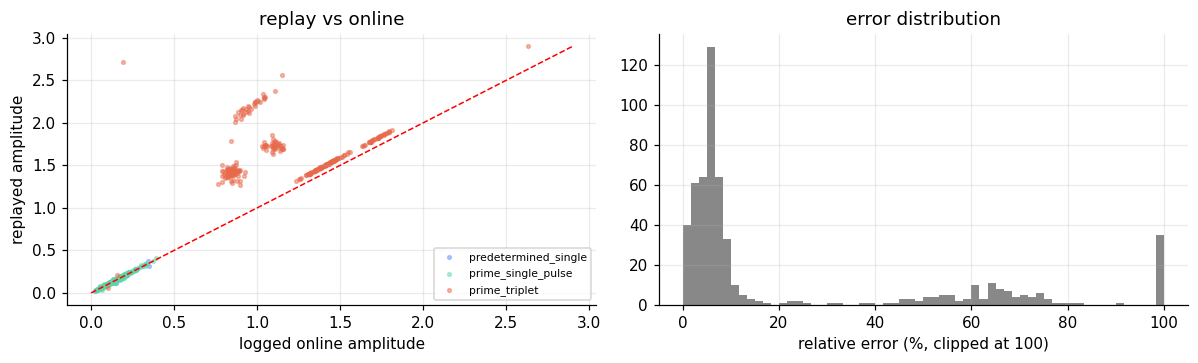


  *** The re-derived fit differs from the online one (r = 0.906). ***
  fitting_info is never written to disk, and the calibration path cannot be
  replayed exactly either: preprocess_calibration ESTIMATES SOUND/SSP-SIR from
  the calibration block, and it needs the ICA-window epochs, which
  save_raw_buffers does not store. So position/orientation/window are
  necessarily approximate here.

  Read the per-condition rows above before deciding what is usable. Amplitudes
  are far more sensitive to the exact window on artifact-dominated triplets than
  on single pulses, so single-pulse agreement is the number that matters for a
  single-pulse analysis.

  Two lines in run_calibration() would remove this uncertainty entirely:
      np.save(self.results_dir / 'dipole_fitting_info.npy',
              self.dipole_fitter.fitting_info, allow_pickle=True)
  This notebook picks that file up automatically if it exists.


In [43]:
from scipy.stats import spearmanr

v = DIP.dropna(subset=["logged_amp"])
DIP_REPRO = {}
if len(v):
    rows = []
    for label, s in [("ALL", v)] + [(c, v[v.condition == c]) for c in sorted(v.condition.unique())]:
        if len(s) < 3:
            continue
        rel = (s.amp_free - s.logged_amp).abs() / s.logged_amp.abs()
        rows.append(dict(
            group=label, n=len(s),
            pearson=float(np.corrcoef(s.amp_free, s.logged_amp)[0, 1]),
            spearman=float(spearmanr(s.amp_free, s.logged_amp).statistic),
            median_rel_err_pct=float(rel.median() * 100),
            p95_rel_err_pct=float(rel.quantile(.95) * 100),
            max_abs_diff=float((s.amp_free - s.logged_amp).abs().max())))
    REPRO = pd.DataFrame(rows).set_index("group").round(4)
    display(REPRO)
    DIP_REPRO = REPRO.to_dict("index")

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    for c, colr in zip(sorted(v.condition.unique()), ["#5b8ff9", "#5ad8a6", "#e8684a"]):
        s = v[v.condition == c]
        ax[0].scatter(s.logged_amp, s.amp_free, s=6, alpha=.45, label=c, color=colr)
    lim = [0, max(v.logged_amp.max(), v.amp_free.max())]
    ax[0].plot(lim, lim, "r--", lw=1)
    ax[0].set(xlabel="logged online amplitude", ylabel="replayed amplitude",
              title="replay vs online"); ax[0].legend(fontsize=7)
    rel_all = (v.amp_free - v.logged_amp).abs() / v.logged_amp.abs()
    ax[1].hist(np.clip(rel_all * 100, 0, 100), bins=60, color="#888")
    ax[1].set(xlabel="relative error (%, clipped at 100)", title="error distribution")
    plt.tight_layout(); plt.show()

    r_all = REPRO.loc["ALL", "pearson"]
    if FI_PATH.exists():
        print("\n  fitting_info was loaded from disk, so any residual difference comes from the")
        print("  preprocessing replay rather than from the dipole model.")
    elif r_all > 0.999:
        print("\n  Faithful. The re-derived fitting_info matches the online one closely enough")
        print("  that everything below describes the real session.")
    else:
        print(f"\n  *** The re-derived fit differs from the online one (r = {r_all:.3f}). ***")
        print("  fitting_info is never written to disk, and the calibration path cannot be")
        print("  replayed exactly either: preprocess_calibration ESTIMATES SOUND/SSP-SIR from")
        print("  the calibration block, and it needs the ICA-window epochs, which")
        print("  save_raw_buffers does not store. So position/orientation/window are")
        print("  necessarily approximate here.")
        print("\n  Read the per-condition rows above before deciding what is usable. Amplitudes")
        print("  are far more sensitive to the exact window on artifact-dominated triplets than")
        print("  on single pulses, so single-pulse agreement is the number that matters for a")
        print("  single-pulse analysis.")
        print("\n  Two lines in run_calibration() would remove this uncertainty entirely:")
        print("      np.save(self.results_dir / 'dipole_fitting_info.npy',")
        print("              self.dipole_fitter.fitting_info, allow_pickle=True)")
        print("  This notebook picks that file up automatically if it exists.")
else:
    print("no logged amplitudes to compare against")


### 7.2 · What the fit looks like per trial


amplitude by condition:


amp_free         amp_fixed         r2_free         r2_fixed        
                        count  median     count  median   count  median    count  median
condition                                                                               
predetermined_single       67  0.1204        67  0.0840      67  0.6859       67  0.3669
prime_single_pulse        228  0.1289       228  0.0889     228  0.6852      228  0.3467
prime_triplet             261  1.5490       261  1.4932     261  0.3705      261  0.2591


free-orientation R2 is guaranteed >= fixed (3 free parameters vs 1):
   holds on 100.0% of trials
Amplitude carries NO such guarantee -- the two models take independent argmaxes:
   amp_fixed > amp_free on 11.3% of trials


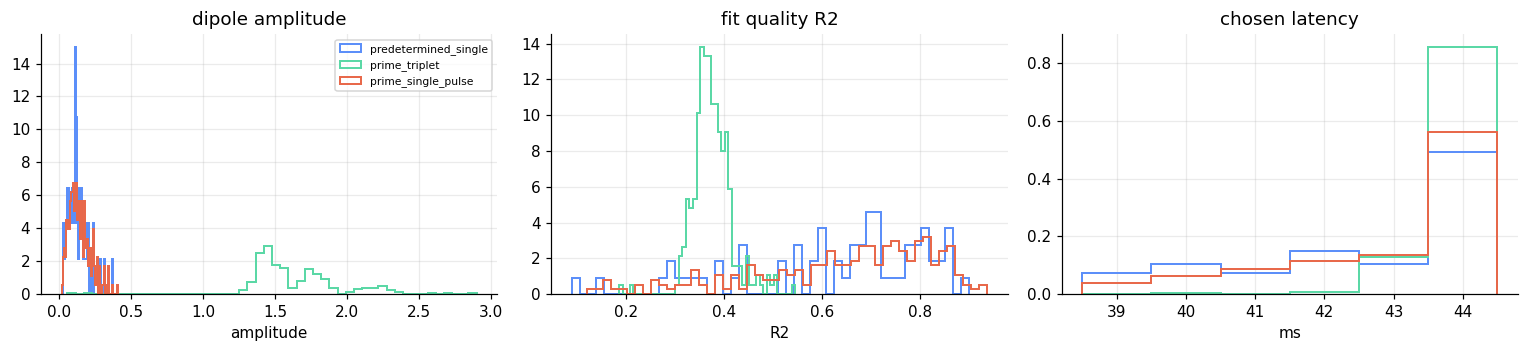


chosen latency within the fitted window:


latency_ms,39.0,40.0,41.0,42.0,43.0,44.0
condition,,,,,,
predetermined_single,5,7,5,10,7,33
prime_single_pulse,9,14,20,26,31,128
prime_triplet,0,1,0,2,34,224


A latency piling up at a window edge suggests the true peak lies outside it.

orientation agreement with the calibration orientation (|cos| close to 1 = stable):


,mean,50%,min
condition,,,
predetermined_single,0.677,0.741,0.026
prime_single_pulse,0.657,0.738,0.006
prime_triplet,0.790,0.794,0.647


In [44]:
print("amplitude by condition:")
display(DIP.groupby("condition")[["amp_free", "amp_fixed", "r2_free", "r2_fixed"]]
           .agg(["count", "median"]).round(4))

print("\nfree-orientation R2 is guaranteed >= fixed (3 free parameters vs 1):")
print(f"   holds on {100*(DIP.r2_free >= DIP.r2_fixed - 1e-12).mean():.1f}% of trials")
print("Amplitude carries NO such guarantee -- the two models take independent argmaxes:")
print(f"   amp_fixed > amp_free on {100*(DIP.amp_fixed > DIP.amp_free).mean():.1f}% of trials")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.3))
for cond, colr in zip(DIP.condition.unique(), ["#5b8ff9", "#5ad8a6", "#e8684a"]):
    s = DIP[DIP.condition == cond]
    ax[0].hist(s.amp_free, bins=50, histtype="step", lw=1.3, label=cond, density=True, color=colr)
    ax[1].hist(s.r2_free, bins=50, histtype="step", lw=1.3, density=True, color=colr)
    ax[2].hist(s.latency_ms, bins=np.arange(t0 - .5, t1 + 1.5), histtype="step", lw=1.3,
               density=True, color=colr)
ax[0].set(title="dipole amplitude", xlabel="amplitude"); ax[0].legend(fontsize=7)
ax[1].set(title="fit quality R2", xlabel="R2")
ax[2].set(title="chosen latency", xlabel="ms")
plt.tight_layout(); plt.show()

print("\nchosen latency within the fitted window:")
display(DIP.groupby("condition").latency_ms.value_counts().unstack(fill_value=0))
print("A latency piling up at a window edge suggests the true peak lies outside it.")

print(f"\norientation agreement with the calibration orientation (|cos| close to 1 = stable):")
display(DIP.groupby("condition").ori_dot.apply(lambda s: s.abs().describe()[["mean","50%","min"]]).unstack().round(3))


---
## 8 · TEP normalizer — raw amplitude to soft label

`TEPNormalizer.calibrate()` learns from the calibration amplitudes, then `transform` converts
each new amplitude into a label in `[0, 1]`:

```
raw  ->  x scale_factor  ->  EWMA trend (span 25)  ->  detrended = value - trend
     ->  z = (detrended - cal_mean) / cal_std      ->  label = ECDF(z)
```

Two things to watch. `warmup_period == ewma_span == 25`, so `calibrate()` throws away the
first 25 detrended values; with fewer than 25 surviving calibration trials the reference
statistics become NaN, the `< 1e-9` guard does not fire (NaN comparisons are False), and every
label silently becomes 1.0. And the transform **mutates state** — each call appends to the
internal history — so triplets must be excluded or they contaminate the trend for everything
after them.


In [45]:
# ---------------------------------------------------------------- replay the normalizer
NORM = TEPNormalizer()
cal_labels = NORM.calibrate(CAL_AMPS)

print(f"calibration amplitudes in : {len(CAL_AMPS)}")
print(f"ewma_span / warmup_period : {NORM.ewma_span} / {NORM.warmup_period}")
n_stable = max(0, len(CAL_AMPS) - NORM.warmup_period)
print(f"detrended values retained : {n_stable}   (len - warmup)")
print(f"cal_mean {NORM._cal_mean:.6g}   cal_std {NORM._cal_std:.6g}")

healthy = n_stable > 0 and np.isfinite(NORM._cal_mean) and np.isfinite(NORM._cal_std)
print(f"\nnormalizer reference is finite: {healthy}")
if not healthy:
    print("  *** DEGENERATE. Fewer than warmup_period calibration trials survived, so")
    print("      cal_mean/cal_std are NaN, the `_cal_std < 1e-9` guard did not fire, and")
    print("      every label collapses to 1.0. Add an explicit check after calibrate():")
    print("        if n_stable == 0 or not np.isfinite(self._cal_std): raise RuntimeError(...)")
else:
    print(f"  ECDF built on {n_stable} points -> label resolution {1/n_stable:.4f},")
    print(f"  so the maximum attainable label is {1 - 1/n_stable:.4f}.")


calibration amplitudes in : 113
ewma_span / warmup_period : 25 / 25
detrended values retained : 88   (len - warmup)
cal_mean -0.00043594   cal_std 0.0737569

normalizer reference is finite: True
  ECDF built on 88 points -> label resolution 0.0114,
  so the maximum attainable label is 0.9886.


In [46]:
# Replay transform_verbose over the session, in true chronological order, skipping triplets
# exactly as the online gate does.
NORM2 = TEPNormalizer()
NORM2.calibrate(CAL_AMPS)

order = DIP.sort_values("t").reset_index(drop=True)
norm_rows = []
for _, r in order.iterrows():
    is_triplet = r.condition == "prime_triplet"
    rec = dict(stage=r.stage, trial=r.trial, condition=r.condition, t=r.t, raw=r.amp_free)
    if is_triplet:
        rec.update(ewma=np.nan, detrended=np.nan, zscore=np.nan, label=np.nan, updated=False)
    else:
        out = NORM2.transform_verbose(r.amp_free)
        rec.update(ewma=out["ewma"], detrended=out["detrended"],
                   zscore=out["zscore"], label=out["label"], updated=True)
    norm_rows.append(rec)
NORM_DF = pd.DataFrame(norm_rows)

print(f"trials passed to the normalizer : {int(NORM_DF.updated.sum())}")
print(f"triplets withheld               : {int((~NORM_DF.updated).sum())}")
print(f"internal history length         : {len(NORM2._amplitudes)}"
      f"  = {len(CAL_AMPS)} calibration + {int(NORM_DF.updated.sum())} single-pulse")
ok = len(NORM2._amplitudes) == len(CAL_AMPS) + int(NORM_DF.updated.sum())
print(f"no triplet leaked into the history: {ok}")


trials passed to the normalizer : 295
triplets withheld               : 261
internal history length         : 408  = 113 calibration + 295 single-pulse
no triplet leaked into the history: True


In [47]:
# ---------------------------------------------------------------- how much contamination was avoided
med_t = NORM_DF.loc[NORM_DF.condition == "prime_triplet", "raw"].median()
med_s = NORM_DF.loc[NORM_DF.condition != "prime_triplet", "raw"].median()
print(f"median raw amplitude, triplets     : {med_t:.4g}")
print(f"median raw amplitude, single pulses: {med_s:.4g}")
print(f"ratio                              : {med_t/med_s:.2f}x")
print("\nThat ratio is what the triplet gate keeps out of the EWMA and the ECDF. Anything")
print("well above 1 means the gate is doing substantial work -- and it also says the")
print("triplet 'TEP amplitude' is mostly pulse-2/3 artifact inside the 38-50 ms window,")
print("not a TEP.")

# Counterfactual: what the labels would have been WITHOUT the gate.
NORM3 = TEPNormalizer(); NORM3.calibrate(CAL_AMPS)
contam = [NORM3.transform_verbose(r.raw)["label"] if r.condition != "prime_triplet"
          else (NORM3.transform_verbose(r.raw), np.nan)[1]
          for _, r in NORM_DF.iterrows()]
NORM_DF["label_if_contaminated"] = contam
cmp = NORM_DF.dropna(subset=["label", "label_if_contaminated"])
print(f"\ncounterfactual (triplets allowed to update the normalizer), {len(cmp)} labelled trials:")
print(f"  mean label with the gate    : {cmp.label.mean():.4f}")
print(f"  mean label without the gate : {cmp.label_if_contaminated.mean():.4f}")
print(f"  mean |difference|           : {(cmp.label - cmp.label_if_contaminated).abs().mean():.4f}")
print(f"  correlation between them    : {np.corrcoef(cmp.label, cmp.label_if_contaminated)[0,1]:.4f}")


median raw amplitude, triplets     : 1.549
median raw amplitude, single pulses: 0.1265
ratio                              : 12.24x

That ratio is what the triplet gate keeps out of the EWMA and the ECDF. Anything
well above 1 means the gate is doing substantial work -- and it also says the
triplet 'TEP amplitude' is mostly pulse-2/3 artifact inside the 38-50 ms window,
not a TEP.

counterfactual (triplets allowed to update the normalizer), 295 labelled trials:
  mean label with the gate    : 0.5075
  mean label without the gate : 0.0041
  mean |difference|           : 0.5034
  correlation between them    : 0.1328


labels produced: 295
count    295.0000
mean       0.5075
std        0.2945
min        0.0114
10%        0.1136
25%        0.2500
50%        0.5227
75%        0.7841
90%        0.9091
max        0.9886

fraction exactly 0   : 0.0000
fraction at the max  : 0.0068   (max = 0.9886)


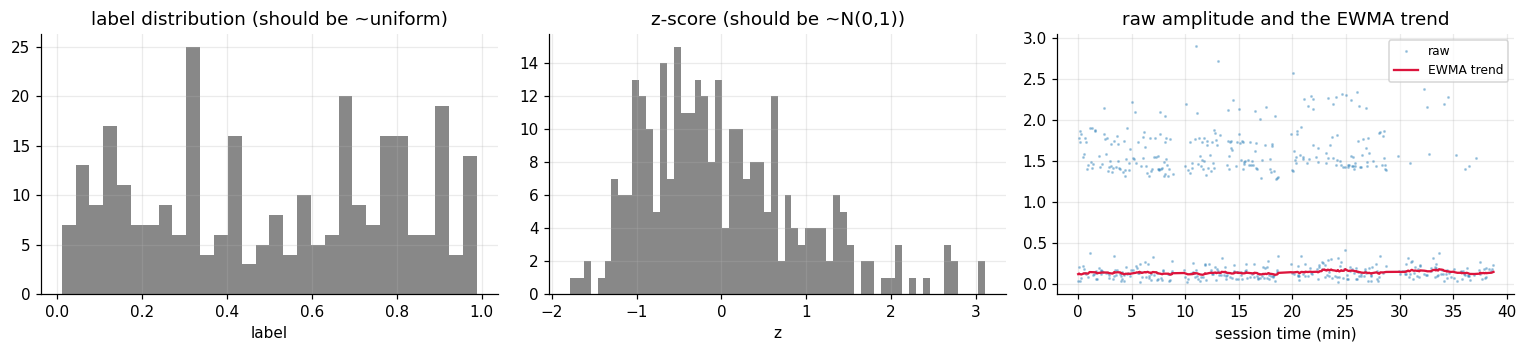


does the EWMA actually remove the drift?
  corr(trial order, raw)     = +0.0860
  corr(trial order, z-score) = -0.0067
  The second should be much closer to zero than the first.


In [48]:
# ---------------------------------------------------------------- health of the label
lab = NORM_DF.label.dropna()
print(f"labels produced: {len(lab)}")
print(lab.describe(percentiles=[.1, .25, .5, .75, .9]).round(4).to_string())
print(f"\nfraction exactly 0   : {(lab == 0).mean():.4f}")
print(f"fraction at the max  : {(lab == lab.max()).mean():.4f}   (max = {lab.max():.4f})")
if lab.nunique() <= 2:
    print("\n  *** The label is degenerate -- see the normalizer health check above. ***")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.3))
ax[0].hist(lab, bins=30, color="#888")
ax[0].set(title="label distribution (should be ~uniform)", xlabel="label")
ax[1].hist(NORM_DF.zscore.dropna(), bins=60, color="#888")
ax[1].set(title="z-score (should be ~N(0,1))", xlabel="z")
s = NORM_DF.dropna(subset=["raw"])
ax[2].plot((s.t - s.t.min()) / 60, s.raw, ".", ms=2, alpha=.3, label="raw")
s2 = NORM_DF.dropna(subset=["ewma"])
ax[2].plot((s2.t - s2.t.min()) / 60, s2.ewma, lw=1.5, color="crimson", label="EWMA trend")
ax[2].set(title="raw amplitude and the EWMA trend", xlabel="session time (min)")
ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

sp = NORM_DF.dropna(subset=["label"]).reset_index(drop=True)
print("\ndoes the EWMA actually remove the drift?")
print(f"  corr(trial order, raw)     = {np.corrcoef(sp.index, sp.raw)[0,1]:+.4f}")
print(f"  corr(trial order, z-score) = {np.corrcoef(sp.index, sp.zscore)[0,1]:+.4f}")
print("  The second should be much closer to zero than the first.")


In [49]:
# ---------------------------------------------------------------- validate against the log
have = [c for c in ["tep_amplitude", "tep_ewma", "tep_detrended", "tep_zscore"]
        if c in IV.columns and IV[c].notna().any()]
if have:
    m = NORM_DF.merge(IV[["stage", "trial_in_stage", "condition"] + have],
                      left_on=["stage", "trial", "condition"],
                      right_on=["stage", "trial_in_stage", "condition"])
    pairs = [("label", "tep_amplitude"), ("ewma", "tep_ewma"),
             ("detrended", "tep_detrended"), ("zscore", "tep_zscore")]
    rows = []
    for mine, theirs in pairs:
        if theirs not in m.columns:
            continue
        s = m.dropna(subset=[mine, theirs])
        if not len(s):
            rows.append((mine, theirs, 0, np.nan, np.nan)); continue
        rows.append((mine, theirs, len(s),
                     float(np.corrcoef(s[mine], s[theirs])[0, 1]),
                     float((s[mine] - s[theirs]).abs().max())))
    display(pd.DataFrame(rows, columns=["replayed", "logged", "n", "pearson r", "max |diff|"]))
    print("These will not be bit-identical because the dipole amplitudes feeding the")
    print("normalizer were themselves re-derived (section 7). A high correlation with a")
    print("small max difference means the reconstruction is sound.")
else:
    print("no normalizer columns in the log to compare against "
          "-- add the extended TEP logging to enable this check.")


,replayed,logged,n,pearson r,max |diff|
0,label,tep_amplitude,295,0.990735,0.233542
1,ewma,tep_ewma,295,0.997044,0.008018
2,detrended,tep_detrended,295,0.992756,0.039259
3,zscore,tep_zscore,295,0.992756,0.709316


These will not be bit-identical because the dipole amplitudes feeding the
normalizer were themselves re-derived (section 7). A high correlation with a
small max difference means the reconstruction is sound.


---
## 9 · Reconciliation

One table. If the post-stimulus row is not 100%, nothing in section 6 can be trusted.


In [50]:
checks = []

checks.append(("preprocess_post decision vs postprocessing_failed",
               f"{((POST.outcome != 'KEPT') == POST.logged_fail).mean()*100:.2f}%",
               len(POST)))
checks.append(("gate statistics reproduce the labelled decision",
               f"{(POST.outcome == POST.outcome_from_stats).mean()*100:.2f}%", len(POST)))

if "preprocessing_failed" in IV.columns and len(pd_tr):
    mm = PRE.merge(pd_tr[["stage", "trial_in_stage", "preprocessing_failed"]],
                   left_on=["stage", "trial"], right_on=["stage", "trial_in_stage"])
    checks.append(("preprocess_pre vs preprocessing_failed (predetermined only)",
                   f"{(((mm.outcome != 'KEPT') == mm.preprocessing_failed.astype(bool)).mean())*100:.2f}%",
                   len(mm)))

if PREDICTIONS is not None and PROFILES["check_qc"] is not None:
    n_qc = len(PROFILES["check_qc"]); n_pr = len(PROFILES["predict"])
    checks.append(("check_qc calls - predict calls == logged qc_failures",
                   f"{n_qc - n_pr} vs {int(IV.qc_failures.sum())}", n_qc))
    lastp = PREDICTIONS.sort_values("attempt").groupby(["stage", "trial_in_stage"]).tail(1)
    mp = IV.merge(lastp, on=["stage", "trial_in_stage"], suffixes=("_t", "_p"))
    dd = (mp.prediction_probability - mp.probability).abs()
    checks.append(("trials_intervention.prediction_probability vs last logged attempt",
                   f"max diff {np.nanmax(dd):.2e}", len(mp)))

vv = DIP.dropna(subset=["logged_amp"])
if len(vv):
    checks.append(("replayed dipole amplitude vs tep_amplitude_raw",
                   f"r = {np.corrcoef(vv.amp_free, vv.logged_amp)[0,1]:.6f}", len(vv)))

RECON = pd.DataFrame(checks, columns=["check", "result", "n"])
display(RECON)

exact = ((POST.outcome != "KEPT") == POST.logged_fail).mean() == 1.0
print(("\nPost-stimulus replay is EXACT. Sections 6-8 describe the real session."
       if exact else
       "\n*** Post-stimulus replay is NOT exact -- investigate before trusting section 6. ***"))


,check,result,n
0,preprocess_post decision vs postprocessing_failed,100.00%,800
1,gate statistics reproduce the labelled decision,100.00%,800
2,preprocess_pre vs preprocessing_failed (predet...,100.00%,67
3,check_qc calls - predict calls == logged qc_fa...,284 vs 284,2213
4,trials_intervention.prediction_probability vs ...,max diff 6.10e-02,720
5,replayed dipole amplitude vs tep_amplitude_raw,r = 0.905904,556



Post-stimulus replay is EXACT. Sections 6-8 describe the real session.


---
## 10 · Findings

The checks below are computed, not asserted. Each one prints its own verdict, so re-running
this notebook on a different session gives a fresh answer rather than a repeat of this one.


In [51]:
findings = []


def flag(severity, area, msg):
    findings.append(dict(severity=severity, area=area, finding=msg))


# --- normalizer degeneracy
if not (n_stable > 0 and np.isfinite(NORM._cal_std)):
    flag("HIGH", "normalizer",
         f"Only {len(CAL_AMPS)} calibration trials vs warmup_period {NORM.warmup_period}: "
         "cal_mean/cal_std are NaN, the guard does not fire, every label becomes 1.0.")

# --- label saturation
if lab.nunique() <= 2:
    flag("HIGH", "normalizer", "The soft label is degenerate (<=2 distinct values).")

# --- gate imbalance between conditions
rj = POST.assign(rej=POST.outcome != "KEPT").groupby("condition").rej.mean()
if {"prime_single_pulse", "predetermined_single"} <= set(rj.index):
    ratio = rj["predetermined_single"] / max(rj["prime_single_pulse"], 1e-9)
    if ratio > 1.5:
        flag("HIGH", "gates",
             f"Rejection is condition-dependent: predetermined_single "
             f"{100*rj['predetermined_single']:.1f}% vs prime_single_pulse "
             f"{100*rj['prime_single_pulse']:.1f}% ({ratio:.1f}x). PRIME only fires when the "
             "pre-stim QC passes, so its surviving trials are pre-selected. Confound for any "
             "PRIME-vs-control comparison.")

# --- one channel dominating gate 3
if len(rej3):
    dom = rej3.local_worst_channel.value_counts()
    share = dom.iloc[0] / len(rej3)
    if share > 0.5:
        sev = "HIGH" if dom.index[0] not in bads else "MEDIUM"
        flag(sev, "hardware",
             f"{dom.index[0]} is the worst channel on {share:.0%} of gate-3 rejections"
             + ("" if dom.index[0] in bads else
                " and is NOT in the calibration bad-channel list, so it was never "
                "interpolated -- it degraded mid-session."))

# --- gate drift
for col, thr, nm in [("ocular_z", oc_thr, "gate 1"), ("global_z", g_hi, "gate 2"),
                     ("local_z_max", l_thr, "gate 3")]:
    shift = POST[col].median() - CALPOST[col].median()
    if abs(shift) > 0.2:
        flag("MEDIUM", "gates",
             f"{nm} statistic sits {shift:+.2f} z away from its calibration reference "
             "(median), yet the reference is frozen. The gate has silently changed strictness.")

# --- block-level collapse
byblock = (POST.assign(rej=POST.outcome != "KEPT")
               .pivot_table(index="condition", columns="stage", values="rej", aggfunc="mean") * 100)
for cond in byblock.index:
    v = byblock.loc[cond].dropna()
    if len(v) > 1 and v.max() > 2 * max(v.median(), 1) and v.max() > 50:
        flag("HIGH", "session",
             f"{cond} rejection reaches {v.max():.0f}% in {v.idxmax()} against a median of "
             f"{v.median():.0f}% -- something changed at that block boundary.")

# --- triplet contamination magnitude
if np.isfinite(med_t) and np.isfinite(med_s) and med_t / med_s > 3:
    flag("INFO", "normalizer",
         f"Triplet amplitudes are {med_t/med_s:.1f}x singles. The triplet gate is essential; "
         "the values themselves are artifact, not TEP.")

# --- prediction saturation
if PREDICTIONS is not None:
    trg = PREDICTIONS[PREDICTIONS.triggered].groupby(
        ["stage", "trial_in_stage"]).t_since_trial_start.max()
    used = (trg.max() - ITI_MIN) / (ITI_MAX - ITI_MIN)
    if used < 0.1:
        flag("MEDIUM", "classifier",
             f"Every pulse fired within {1000*(trg.max()-ITI_MIN):.0f} ms of ITI_MIN; only "
             f"{used*100:.1f}% of the decision window was ever used. The classifier is "
             "saturating, so brain-state selection is doing little work.")

# --- duplicate prediction rows
if PREDICTIONS is not None:
    dup = PREDICTIONS[PREDICTIONS.triggered].groupby(["stage", "trial_in_stage"]).size()
    if (dup > 1).any():
        flag("LOW", "logging",
             f"{int((dup>1).sum())} trials have more than one triggered attempt logged "
             "(counter reset at block boundaries); prime_attempts is inflated by one there.")

# --- fitting_info not persisted
if not FI_PATH.exists():
    r_all = DIP_REPRO.get("ALL", {}).get("pearson", np.nan)
    r_sp = DIP_REPRO.get("prime_single_pulse", {}).get("pearson", np.nan)
    sev = "HIGH" if (np.isfinite(r_all) and r_all < 0.99) else "MEDIUM"
    flag(sev, "reproducibility",
         "DipoleFitter.fitting_info is never written to disk, so position, orientation and "
         f"sub-window had to be re-derived (replay vs online r = {r_all:.3f} overall, "
         f"{r_sp:.3f} on single pulses). Saving it in run_calibration() makes the offline "
         "fit exact; this notebook loads it automatically if present.")

# --- latency piling up at a window edge
if len(DIP):
    edge = DIP[DIP.condition != "prime_triplet"].latency_ms
    if len(edge) and (edge == edge.max()).mean() > 0.4 and edge.max() >= t1 - 1e-6:
        flag("MEDIUM", "dipole",
             f"{100*(edge == edge.max()).mean():.0f}% of single-pulse trials pick the LAST "
             f"sample of the fitted window ([{t0:.0f}, {t1:.0f}] ms). A peak pressed against "
             "the window edge suggests the real component lies later than the window allows.")

# --- single-trial orientation instability
if len(DIP):
    od = DIP.loc[DIP.condition != "prime_triplet", "ori_dot"].abs()
    if len(od) and od.median() < 0.85:
        flag("INFO", "dipole",
             f"Single-trial free orientations agree with the calibration orientation only "
             f"moderately (median |cos| = {od.median():.2f}). Expected for single trials at "
             "this SNR, but it means the free-orientation amplitude is not measuring a fixed "
             "source direction.")

F = pd.DataFrame(findings)
if len(F):
    F["severity"] = pd.Categorical(F.severity, ["HIGH", "MEDIUM", "LOW", "INFO"], ordered=True)
    F = F.sort_values("severity").reset_index(drop=True)
    pd.set_option("display.max_colwidth", 140)
    display(F)
else:
    print("No issues flagged by the automated checks.")


,severity,area,finding
0,HIGH,gates,Rejection is condition-dependent: predetermined_single 16.2% vs prime_single_pulse 5.0% (3.2x). PRIME only fires when the pre-stim QC pa...
1,HIGH,hardware,"O2 is the worst channel on 100% of gate-3 rejections and is NOT in the calibration bad-channel list, so it was never interpolated -- it ..."
2,HIGH,session,prime_triplet rejection reaches 91% in intervention_block_4 against a median of 32% -- something changed at that block boundary.
3,HIGH,reproducibility,"DipoleFitter.fitting_info is never written to disk, so position, orientation and sub-window had to be re-derived (replay vs online r = 0..."
4,MEDIUM,gates,"gate 1 statistic sits +0.25 z away from its calibration reference (median), yet the reference is frozen. The gate has silently changed s..."
5,MEDIUM,gates,"gate 2 statistic sits +3.19 z away from its calibration reference (median), yet the reference is frozen. The gate has silently changed s..."
6,MEDIUM,gates,"gate 3 statistic sits +0.75 z away from its calibration reference (median), yet the reference is frozen. The gate has silently changed s..."
7,MEDIUM,dipole,"55% of single-pulse trials pick the LAST sample of the fitted window ([39, 44] ms). A peak pressed against the window edge suggests the ..."
8,LOW,logging,2 trials have more than one triggered attempt logged (counter reset at block boundaries); prime_attempts is inflated by one there.
9,INFO,normalizer,"Triplet amplitudes are 12.2x singles. The triplet gate is essential; the values themselves are artifact, not TEP."


In [52]:
# ---------------------------------------------------------------- export
per_trial = POST.merge(
    DIP[["stage", "trial", "amp_free", "amp_fixed", "r2_free", "latency_ms", "ori_dot"]],
    on=["stage", "trial"], how="left").merge(
    NORM_DF[["stage", "trial", "ewma", "detrended", "zscore", "label"]],
    on=["stage", "trial"], how="left").merge(
    PRE[["stage", "trial", "z_global", "z_local_max", "worst_channel"]].rename(
        columns={"z_global": "pre_z_global", "z_local_max": "pre_z_local_max",
                 "worst_channel": "pre_worst_channel"}),
    on=["stage", "trial"], how="left")

out_csv = OUT_DIR / "per_trial_diagnostics.csv"
per_trial.to_csv(out_csv, index=False)
print(f"per-trial diagnostics -> {out_csv}   ({per_trial.shape[0]} rows x {per_trial.shape[1]} cols)")
print("columns:", ", ".join(per_trial.columns))

if len(F):
    out_f = OUT_DIR / "findings.csv"
    F.to_csv(out_f, index=False)
    print(f"findings              -> {out_f}")

for name, df in [("gate_sweep_ocular", SWEEP1), ("waterfall", WATERFALL),
                 ("reconciliation", RECON), ("windows", WINDOWS)]:
    df.to_csv(OUT_DIR / f"{name}.csv")
print(f"supporting tables     -> {OUT_DIR}")


per-trial diagnostics -> D:\Linus\Loop\BIDS\sub-Pilot002\ses-prime\diagnostics\per_trial_diagnostics.csv   (800 rows x 29 cols)
columns: stage, trial, condition, t, logged_fail, logged_amp, outcome, dipole_shape, ocular_z_c1, ocular_z_c14, ocular_z, global_z, local_z_max, local_worst_channel, local_n_over, local_over_channels, outcome_from_stats, amp_free, amp_fixed, r2_free, latency_ms, ori_dot, ewma, detrended, zscore, label, pre_z_global, pre_z_local_max, pre_worst_channel
findings              -> D:\Linus\Loop\BIDS\sub-Pilot002\ses-prime\diagnostics\findings.csv
supporting tables     -> D:\Linus\Loop\BIDS\sub-Pilot002\ses-prime\diagnostics


---

### How to reuse this

Point section 0 at another session and re-run. Every threshold, window and rejection rule is
read from prime's live config, and the instrumented functions are compiled from prime's live
source, so the notebook tracks the code rather than a snapshot of it. If prime's source changes
shape — a gate added, a `return None` moved — `clone_labelled` and `clone_until` raise
immediately rather than reporting something plausible and wrong.

**The three cells to read first on a new session:** the reconciliation table in section 9, the
attrition waterfall in 6.1, and the findings table in section 10.
